# Local Redundancy across biologically-plausible learning rules

**A self-contained reimplementation.** This notebook measures the *local
redundancy* plasticity estimator of "Local Redundancy: An Information-Theoretic
Measure of Plasticity from Synthetic Memorization" (arXiv:2607.13432) on
networks trained with the biologically-plausible learning rules of Galloni,
Peddada, Chennawar & Milstein, *Cellular and subcellular specialization enables
biology-constrained deep learning*, Cell Reports 45:117159 (2026).

Nothing is installed or cloned. Everything the experiment needs from the EIANN
library (https://github.com/Milstein-Lab/EIANN) is reimplemented below, so the
notebook runs top-to-bottom in a fresh Colab CPU runtime.

---

## What changed relative to the original notebook

The original notebook used the `EIANN` package directly. Auditing it against
the published EIANN v1.0.0 source turned up six substantive issues. Each is
fixed here, and each fix is checked by an assertion in the self-test section.

| # | Issue in the original | Fix |
|---|---|---|
| 1 | `local_redundancy_eiann` differentiated w.r.t. `[p for p in network.parameters() if p.requires_grad]`. EIANN sets `weight.requires_grad = False` on every projection and only `Backprop.__init__` flips it back, so for Hebbian/Oja/BCM/LDS/TCH/BTSP the estimate was computed **over the biases only**, while Backprop's covered all weights. Every cross-rule comparison was apples-to-oranges. | `plastic_parameters()` returns every parameter the network's rules actually modify, and `_grad_enabled()` temporarily makes them differentiable. Identical parameter set for every rule. |
| 2 | The bound is `E_y‖∇ log P(y‖x)‖²`, a **per-sample** average of squared norms. The original built one `n_probe`-sized batch, averaged the loss, then squared the gradient. With self-sampled targets the per-sample gradients are near mean-zero, so this estimates ~`1/n` of the intended quantity plus noise. | `local_redundancy()` loops over probe samples and averages squared norms. A demo in the self-tests shows the size of the discrepancy. |
| 3 | `Network.forward` only tracks autograd for the last `backward_steps` of `forward_steps`, so the probe gradient was of the final settling step only. | `_grad_enabled()` sets `backward_steps = forward_steps` for the duration of the probe and restores it afterwards. |
| 4 | **The dendritic network could not compute a local error.** LDS/TCH/BTSP read `pop.dendritic_state` as the error, which is only an error if top-down excitation is cancelled by dendritic inhibition. The original had only an excitatory top-down projection with `weight_bounds=(0, None)` cloned from non-negative forward weights, so `dendritic_state ≥ 0` always: no negative plateaus, and the "error" was just top-down drive. Hence LDS/TCH/BTSP sat near chance while Backprop reached 0.85. | `build_dendritic_network` adds the Dend-I interneuron population that relays the *forward* top-down signal (`update_phase='F'`, so it stays frozen while the E populations re-equilibrate under the output nudge) and inhibits the apical dendrite with the matched weights. `dendritic_balance()` asserts the cancellation holds. |
| 5 | The E/I network applied no weight normalisation. `Hebb_WeightNorm` does **not** normalise anything itself — normalisation comes from a `normalize_weight` weight constraint on the projection. Plain Hebbian therefore diverged (weight norm 6 → 14, training gradient norm 2.9e6). | `weight_norm` is a first-class architecture argument, applied identically to every rule so the comparison stays controlled. |
| 6 | Training was chunked by repeatedly calling `network.train()`, which calls `reset_history()` on entry and re-iterates the dataloader from scratch — so every 1000-step chunk drew the *first* 1000 samples of a fresh shuffle, discarded its loss history, and reset BTSP's eligibility traces. | `Network.train_steps()` consumes a persistent infinite iterator and only reinitialises rule state on the first chunk. |

Smaller things also corrected: baseline metrics (`weight_norm`, `distance_from_init`)
now cover only plastic parameters rather than including frozen inhibitory and
cloned top-down weights; `train_gradient_norm` uses the same per-sample
convention as the estimator; the dead MNIST probe-image branch is gone.

### One caveat to check yourself

I could not retrieve arXiv:2607.13432 while writing this, so the estimator is
implemented from the formulas stated in the original notebook plus standard
Fisher-information theory: with `y ~ P_θ(·|x)`, `R**_n(θ₀,ε) ≥ ε·E_y‖∇_θ log P_θ(y|x)‖²`,
in the Gaussian case `P = N(f(x), σ²I)` (Corollary 3.6) and the categorical case
`P = Cat(softmax f(x))` (Theorem 3.4). **Please check §3.6 of the paper** for the
exact probe-image construction and the `σ` / `ε` conventions before quoting
absolute numbers. Relative comparisons at fixed `n_probe`, `σ`, `ε` are the
meaningful quantity either way.

In [ ]:
import sys, math, contextlib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.nn import MSELoss
from torch.optim import SGD, Adam
from collections import defaultdict
from copy import deepcopy

print('python', sys.version.split()[0])
print('torch ', torch.__version__)
print('numpy ', np.__version__)

torch.manual_seed(0)
np.random.seed(0)

python 3.12.13
torch  2.11.0+cpu
numpy  2.0.2


---
# Part 1 — A minimal EIANN

The next five cells reimplement the parts of EIANN v1.0.0
(Zenodo 10.5281/zenodo.18602556) that this experiment touches. Function
bodies are transcribed from the published source so that results remain
comparable to the paper; where behaviour is subtle (plateau selection order,
constraint application order) the comment says so.

## 1.1 Activations, weight initialisers, weight constraints

In [ ]:
# =====================================================================
# 1. Activations, weight initialisers, weight constraints
# =====================================================================

def linear(x):
    return x


def srelu(x, min=0.0, max=1.0):
    return torch.clamp(x, min, max)


def relu(x):
    return torch.nn.functional.relu(x)


def polynomial(x, a=1.0, n=2.0):
    return a * torch.clamp(x, 0.0) ** n


ACTIVATIONS = {'linear': linear, 'srelu': srelu, 'relu': relu, 'polynomial': polynomial}


def get_scaled_rectified_sigmoid(th, peak, x=None, ylim=None):
    """Sigmoid rescaled to hit ylim over the x range. Used for BTSP depression."""
    if x is None:
        x = (0.0, 1.0)
    if ylim is None:
        ylim = (0.0, 1.0)
    if th < x[0] or th > x[-1]:
        raise ValueError('th %.2E out of range [%.2E, %.2E]' % (th, x[0], x[-1]))
    if peak == th:
        raise ValueError('peak and th cannot be equal')
    slope = 2.0 / (peak - th)
    y = lambda v: 1.0 / (1.0 + math.exp(-slope * (v - th)))
    start_val = y(x[0])
    end_val = y(x[-1])
    amp = end_val - start_val
    target_amp = ylim[1] - ylim[0]
    return lambda xi: (target_amp / amp) * (
        1.0 / (1.0 + torch.exp(-slope * (torch.clamp(xi, x[0], x[-1]) - th))) - start_val) + ylim[0]


def scaled_kaiming_init(data, fan_in, scale=1):
    bound = 1.0 / math.sqrt(fan_in) if fan_in > 0 else 0.0
    data.uniform_(-scale * bound, scale * bound)


def half_kaiming_init(data, fan_in, scale=1, bounds=None):
    bound = 1.0 / math.sqrt(fan_in) if fan_in > 0 else 0.0
    if bounds is None:
        raise RuntimeError('half_kaiming_init: bounds required')
    if bounds[0] is not None and bounds[0] >= 0:
        data.uniform_(bounds[0], scale * bound)
    elif bounds[1] is not None and bounds[1] <= 0:
        data.uniform_(-scale * bound, bounds[1])
    else:
        raise RuntimeError('half_kaiming_init: bounds must be >=0 or <=0: %s' % str(bounds))


def no_autapses(projection):
    if projection.pre is projection.post:
        projection.weight.data.fill_diagonal_(0.0)


def normalize_weight(projection, scale, autapses=False, axis=1):
    if not autapses:
        no_autapses(projection)
    weight_sum = torch.sum(torch.abs(projection.weight.data), axis=axis).unsqueeze(1)
    valid_rows = torch.nonzero(weight_sum, as_tuple=True)[0]
    projection.weight.data[valid_rows, :] /= weight_sum[valid_rows, :]
    projection.weight.data *= scale


def clone_weight(projection, source=None, sign=1, scale=1, source2=None, transpose=False):
    """Force a projection to copy another projection's weights ('Post.Pop.Pre.Pop')."""
    if source is None:
        raise Exception('clone_weight: missing required kwarg: source')
    network = projection.post.network
    try:
        s_post_layer, s_post_pop, s_pre_layer, s_pre_pop = source.split('.')
        source_projection = network.layers[s_post_layer].populations[s_post_pop] \
            .projections[s_pre_layer][s_pre_pop]
    except Exception:
        source_projection = network.projections[source]
    w = source_projection.weight.data.clone() * scale * sign
    if source2 is not None:
        s2 = source2.split('.')
        w2 = network.layers[s2[0]].populations[s2[1]].projections[s2[2]][s2[3]].weight.data.clone()
        w = w * w2
    if transpose:
        w = w.T
    if w.shape != projection.weight.data.shape:
        raise Exception('clone_weight: shape mismatch; target %s %s, source %s %s' %
                        (projection.name, tuple(projection.weight.data.shape),
                         source_projection.name, tuple(w.shape)))
    projection.weight.data = w.contiguous()


WEIGHT_CONSTRAINTS = {'normalize_weight': normalize_weight,
                      'clone_weight': clone_weight,
                      'no_autapses': no_autapses}

## 1.2 Learning-rule base classes and Backprop

`LearningRule` is the no-op base class EIANN uses for frozen projections.
Note `Backprop.__init__` setting `requires_grad = True` — this single line is
the origin of issue #1 in the table above.

In [ ]:
# =====================================================================
# 2. Learning-rule base classes
# =====================================================================

class LearningRule(object):
    """No-op base class (EIANN uses this for frozen projections)."""
    is_plastic = False

    def __init__(self, projection, learning_rate=None):
        self.projection = projection
        if learning_rate is None:
            learning_rate = projection.post.network.learning_rate
        self.learning_rate = learning_rate

    def step(self):
        pass

    def reinit(self):
        pass

    def update(self):
        pass

    @classmethod
    def backward(cls, network, output, target, store_history=False):
        pass

    @classmethod
    def shared_backward_methods(cls, learning_rule):
        return learning_rule.__class__.backward.__func__ is cls.backward.__func__


class BiasLearningRule(object):
    is_plastic = False

    def __init__(self, population, learning_rate=None):
        self.population = population
        if learning_rate is None:
            learning_rate = population.network.learning_rate
        self.learning_rate = learning_rate

    def step(self):
        pass

    def reinit(self):
        pass

    def update(self):
        pass

    @classmethod
    def backward(cls, network, output, target, store_history=False):
        pass


# ---------------------------------------------------------------------
# 2a. Backprop
# ---------------------------------------------------------------------

class Backprop(LearningRule):
    is_plastic = True

    def __init__(self, projection, learning_rate=None):
        super().__init__(projection, learning_rate)
        projection.weight.requires_grad = True

    @classmethod
    def backward(cls, network, output, target, store_history=False):
        loss = network.criterion(output, target)
        network.optimizer.zero_grad()
        loss.backward()
        network.optimizer.step()


class BackpropBias(BiasLearningRule):
    is_plastic = True

    def __init__(self, population, learning_rate=None):
        super().__init__(population, learning_rate)
        population.bias.requires_grad = True

    backward = Backprop.backward

## 1.3 Purely local Hebbian-family rules

`Hebb_WeightNorm`, `Hebb_WeightNorm_4`, `Ojas_rule`, `BCM_4`. All of these
mutate `projection.weight.data` in place and never touch autograd.

In [ ]:
# ---------------------------------------------------------------------
# 2b. Purely local Hebbian-family rules
# ---------------------------------------------------------------------

class Hebb_WeightNorm(LearningRule):
    """dW = lr * sign * outer(post, pre). Bounded growth requires a
    'normalize_weight' weight_constraint on the projection."""
    is_plastic = True

    def __init__(self, projection, sign=1, learning_rate=None, forward_only=False):
        super().__init__(projection, learning_rate)
        self.sign = sign
        self.forward_only = forward_only

    def step(self):
        p = self.projection
        if p.direction in ('forward', 'F'):
            post = p.post.forward_activity if self.forward_only else p.post.activity
            pre = p.pre.forward_activity if self.forward_only else p.pre.activity
        else:
            post = p.post.forward_activity if self.forward_only else p.post.activity
            pre = p.pre.forward_prev_activity if self.forward_only else p.pre.prev_activity
        dw = torch.outer(post.detach(), pre.detach())
        p.weight.data += (self.sign if self.sign > 0 else -1) * self.learning_rate * dw


class Hebb_WeightNorm_4(Hebb_WeightNorm):
    """Same, but with firing rates bounded to [0, 1] first."""

    def step(self):
        p = self.projection
        if p.direction in ('forward', 'F'):
            post = p.post.forward_activity if self.forward_only else p.post.activity
            pre = p.pre.forward_activity if self.forward_only else p.pre.activity
        else:
            post = p.post.forward_activity if self.forward_only else p.post.activity
            pre = p.pre.forward_prev_activity if self.forward_only else p.pre.prev_activity
        dw = torch.outer(torch.clamp(post, 0, 1), torch.clamp(pre, 0, 1)).detach().clone()
        p.weight.data += (self.sign if self.sign > 0 else -1) * self.learning_rate * dw


class Ojas_rule(LearningRule):
    """dW = lr * (y x^T - y^2 W)."""
    is_plastic = True

    def __init__(self, projection, learning_rate=None, forward_only=False):
        super().__init__(projection, learning_rate)
        self.forward_only = forward_only

    def step(self):
        p = self.projection
        post = p.post.forward_activity if self.forward_only else p.post.activity
        post = torch.clamp(post, 0, 1)
        if p.direction in ('forward', 'F'):
            pre = p.pre.forward_activity if self.forward_only else p.pre.activity
        else:
            pre = p.pre.forward_prev_activity if self.forward_only else p.pre.prev_activity
        pre = torch.clamp(pre, 0, 1)
        hebb = torch.outer(post, pre)
        decay = (post.unsqueeze(1) ** 2) * p.weight.data
        p.weight.data += self.learning_rate * (hebb - decay).detach().clone()


class BCM_4(LearningRule):
    """dW = lr * sign * outer(post, pre) * (post - theta), with a sliding
    threshold theta integrating post^2 / k with time constant theta_tau."""
    is_plastic = True

    def __init__(self, projection, theta_tau, k, sign=1, learning_rate=None):
        super().__init__(projection, learning_rate)
        self.theta_tau = theta_tau
        self.k = k
        self.sign = sign
        projection.post.theta = torch.ones(projection.post.size,
                                           device=projection.post.network.device) * k

    def reinit(self):
        self.projection.post.BCM_theta_updated = False

    def update(self):
        pop = self.projection.post
        if not getattr(pop, 'BCM_theta_updated', False):
            d = ((-pop.theta + pop.activity.detach() ** 2.0 / self.k) / self.theta_tau).detach().clone()
            pop.theta = pop.theta + d
            pop.BCM_theta_updated = True

    def step(self):
        p = self.projection
        post = p.post.activity.detach().clone()
        pre = p.pre.activity if p.direction in ('forward', 'F') else p.pre.prev_activity
        dw = (torch.outer(post, torch.clamp(pre, 0, 1)) *
              (post - p.post.theta).unsqueeze(1)).detach().clone()
        p.weight.data += (1 if self.sign > 0 else -1) * self.learning_rate * dw

    @classmethod
    def backward(cls, network, output, target, store_history=False):
        for pop in network.populations.values():
            for projection in pop:
                if projection.learning_rule.__class__ is cls:
                    pop.BCM_theta_updated = False
                    break

## 1.4 Dendritic target propagation

The shared backward-phase machinery plus `BP_like_2E` (LDS), `BP_like_2L`,
`Hebbian_Temporal_Contrast` (TCH) and `BTSP_19`.

The mechanism, which the original notebook's architecture did not implement:
a hidden unit's apical dendrite receives top-down excitation from the layer
above *and* inhibition from a Dend-I interneuron carrying the same signal. In
the forward phase the two cancel, so `dendritic_state ≈ 0`. The output is then
nudged toward the target; the E pathway tracks the change but the Dend-I
pathway is frozen, so `dendritic_state` becomes `B(a_above^backward −
a_above^forward)` — a locally computed error. Units with the largest
|dendritic state| emit plateaus, which gate the weight update.

In [ ]:
# ---------------------------------------------------------------------
# 2c. Dendritic target propagation: shared backward machinery
# ---------------------------------------------------------------------

class DendriticBackwardMixin(object):
    """Shared backward-phase machinery for BP_like_2E / BP_like_2L /
    Hebbian_Temporal_Contrast / BTSP_19.

    Local error at a hidden unit == its dendritic state, i.e. the
    difference between top-down excitation and dendritic inhibition.
    Because the Dend-I population's inputs have update_phase='F', its
    activity stays frozen at its forward value while the E populations
    re-equilibrate under the output nudge, so the dendritic state
    becomes (top-down excitation now) - (top-down excitation before)
    == a locally computed error signal.
    """

    @classmethod
    def update_layer_dendritic_state(cls, layer):
        for post_pop in layer:
            if post_pop.backward_projections:
                init = False
                for projection in post_pop:
                    if projection.compartment in ('dend', 'dendrite'):
                        if not init:
                            post_pop.dendritic_state = torch.zeros(
                                post_pop.size, device=post_pop.network.device)
                            init = True
                        pre = projection.pre
                        src = pre.activity if projection.direction in ('forward', 'F') else pre.prev_activity
                        post_pop.dendritic_state = post_pop.dendritic_state + projection(src.detach())
                if init:
                    post_pop.dendritic_state = post_pop.dendritic_state.detach().clamp_(min=-1, max=1)

    @classmethod
    def update_layer_activity(cls, layer, equilibrate=True):
        """Re-equilibrate somatic activity, applying any dendrite->soma nudge."""
        for post_pop in layer:
            post_pop.prev_activity = post_pop.activity
        for post_pop in layer:
            if not (post_pop.backward_projections or post_pop is post_pop.network.output_pop):
                continue
            if equilibrate:
                delta_state = -post_pop.state + post_pop.bias
                for projection in post_pop:
                    if projection.compartment in (None, 'soma'):
                        pre = projection.pre
                        src = pre.activity if projection.direction in ('forward', 'F') else pre.prev_activity
                        delta_state = delta_state + projection(src.detach())
                post_pop.state = (post_pop.state + delta_state / post_pop.tau).detach()
            if hasattr(post_pop, 'dend_to_soma'):
                post_pop.activity = post_pop.activation(post_pop.state + post_pop.dend_to_soma)
            else:
                post_pop.activity = post_pop.activation(post_pop.state)

    @classmethod
    def select_plateau_units(cls, pop, rule, output_pop, target):
        """Compute plateau events and the somatic nudge for one population."""
        if pop is output_pop:
            local_loss = torch.clamp(target - output_pop.activity.detach(), min=-1, max=1)
            output_pop.dendritic_state = local_loss.detach().clone()
            if rule.relu_gate:
                local_loss = local_loss.clone()
                local_loss[output_pop.forward_activity == 0.0] = 0.0
            output_pop.plateau[:] = local_loss.detach().clone()
            output_pop.dend_to_soma[:] = local_loss.detach().clone()
            return

        max_units = math.ceil(rule.max_pop_fraction * pop.size)
        local_loss = pop.dendritic_state.detach().clone()
        if rule.relu_gate:
            local_loss[pop.forward_activity == 0.0] = 0.0

        pos_avail = (local_loss > 0.0).nonzero().squeeze(1)
        if rule.stochastic:
            pos_rel = torch.bernoulli(local_loss[pos_avail]).nonzero().squeeze(1)
        else:
            _, pos_rel = torch.sort(local_loss[pos_avail], descending=True, stable=True)
        pos_idx = pos_avail[pos_rel][:max_units]

        # NB: EIANN applies the negative-rate threshold to local_loss *in place*
        # after selecting the positive candidates, so it also affects the values
        # written for positive plateaus. Reproduced here exactly.
        if getattr(rule, 'neg_rate_th', None) is not None:
            local_loss[pop.forward_activity <= rule.neg_rate_th] = 0.0
        neg_avail = (local_loss < 0.0).nonzero().squeeze(1)
        if rule.stochastic:
            neg_rel = torch.bernoulli(-local_loss[neg_avail]).nonzero().squeeze(1)
        else:
            _, neg_rel = torch.sort(local_loss[neg_avail], descending=True, stable=True)
        neg_idx = neg_avail[neg_rel][-max_units:]

        pop.plateau[pos_idx] = local_loss[pos_idx]
        pop.plateau[neg_idx] = local_loss[neg_idx]
        pop.dend_to_soma[pos_idx] = local_loss[pos_idx]
        pop.dend_to_soma[neg_idx] = local_loss[neg_idx]

    @classmethod
    @torch.no_grad()
    def _backward(cls, network, output, target, equilibrate):
        reversed_layers = list(network)[1:][::-1]
        output_pop = network.output_pop

        for layer in reversed_layers:
            for pop in layer:
                for projection in pop:
                    if projection.learning_rule.__class__ is cls:
                        pop.plateau = torch.zeros(pop.size, device=network.device)
                        pop.dend_to_soma = torch.zeros(pop.size, device=network.device)
                        break

        n_steps = network.forward_steps if equilibrate else 1
        for t in range(n_steps):
            for layer in reversed_layers:
                cls.update_layer_dendritic_state(layer)
                if t == 0:
                    for pop in layer:
                        for projection in pop:
                            if projection.learning_rule.__class__ is cls:
                                cls.select_plateau_units(pop, projection.learning_rule,
                                                         output_pop, target)
                                break
                cls.update_layer_activity(layer, equilibrate=equilibrate)


class BP_like_2E(DendriticBackwardMixin, LearningRule):
    """'LDS' in Galloni et al.  dW = lr * outer(plateau, forward pre-activity).
    Nudged activity is passed top-down but not re-equilibrated laterally."""
    is_plastic = True

    def __init__(self, projection, max_pop_fraction=1.0, stochastic=False,
                 learning_rate=None, relu_gate=False):
        super().__init__(projection, learning_rate)
        self.max_pop_fraction = max_pop_fraction
        self.stochastic = stochastic
        self.relu_gate = relu_gate
        self.neg_rate_th = None

    def step(self):
        p = self.projection
        pre = p.pre.forward_activity if p.direction in ('forward', 'F') else p.pre.forward_prev_activity
        dw = torch.outer(p.post.plateau, torch.clamp(pre, 0, 1))
        p.weight.data += self.learning_rate * dw.detach()

    @classmethod
    def backward(cls, network, output, target, store_history=False):
        cls._backward(network, output, target, equilibrate=False)


class BP_like_2L(DendriticBackwardMixin, LearningRule):
    """Like BP_like_2E but activities re-equilibrate across all layers
    during the backward phase, and the update uses backward-phase
    presynaptic activity."""
    is_plastic = True

    def __init__(self, projection, max_pop_fraction=1.0, stochastic=False,
                 learning_rate=None, relu_gate=False, forward_only=False):
        super().__init__(projection, learning_rate)
        self.max_pop_fraction = max_pop_fraction
        self.stochastic = stochastic
        self.relu_gate = relu_gate
        self.forward_only = forward_only
        self.neg_rate_th = None

    def step(self):
        p = self.projection
        if p.direction in ('forward', 'F'):
            pre = p.pre.forward_activity if self.forward_only else p.pre.activity
        else:
            pre = p.pre.forward_prev_activity if self.forward_only else p.pre.prev_activity
        dw = torch.outer(p.post.plateau, torch.clamp(pre, 0, 1))
        p.weight.data += self.learning_rate * dw.detach()

    @classmethod
    def backward(cls, network, output, target, store_history=False):
        cls._backward(network, output, target, equilibrate=True)


class Hebbian_Temporal_Contrast(BP_like_2L):
    """'TCH' in Galloni et al.  Contrastive Hebbian update (Xie & Seung 2003):
    dW = lr * (post_backward pre_backward^T - post_forward pre_forward^T)."""
    is_plastic = True

    def __init__(self, projection, max_pop_fraction=1.0, stochastic=False,
                 learning_rate=None, relu_gate=True):
        super().__init__(projection, max_pop_fraction=max_pop_fraction,
                         stochastic=stochastic, learning_rate=learning_rate,
                         relu_gate=relu_gate)

    def step(self):
        p = self.projection
        fwd_post = torch.clamp(p.post.forward_activity, 0, 1)
        bwd_post = torch.clamp(p.post.activity, 0, 1).detach().clone()
        if self.relu_gate:
            bwd_post[fwd_post == 0.0] = 0.0
        if p.direction in ('forward', 'F'):
            fwd_pre = torch.clamp(p.pre.forward_activity, 0, 1)
            bwd_pre = torch.clamp(p.pre.activity, 0, 1)
        else:
            fwd_pre = torch.clamp(p.pre.forward_prev_activity, 0, 1)
            bwd_pre = torch.clamp(p.pre.prev_activity, 0, 1)
        dw = (torch.outer(bwd_post, bwd_pre) - torch.outer(fwd_post, fwd_pre)).detach().clone()
        p.weight.data += self.learning_rate * dw

    @classmethod
    def backward(cls, network, output, target, store_history=False):
        cls._backward(network, output, target, equilibrate=True)


class BTSP_19(DendriticBackwardMixin, LearningRule):
    """Behavioural-timescale synaptic plasticity. Positive plateaus drive a
    weight-dependent potentiation/depression rule with eligibility traces
    that span the current and previous sample; negative plateaus drive a
    simple error x presynaptic-rate depression."""
    is_plastic = True

    def __init__(self, projection, neg_rate_th=None, dep_ratio=1.0, dep_th=0.01,
                 dep_width=0.01, max_pop_fraction=1.0, temporal_discount=0.25,
                 stochastic=False, learning_rate=None, relu_gate=True):
        super().__init__(projection, learning_rate)
        self.q_dep = get_scaled_rectified_sigmoid(dep_th, dep_th + dep_width)
        self.neg_rate_th = neg_rate_th
        self.dep_ratio = dep_ratio
        self.max_pop_fraction = max_pop_fraction
        self.temporal_discount = temporal_discount
        self.stochastic = stochastic
        self.relu_gate = relu_gate
        if projection.weight_bounds is None or projection.weight_bounds[1] is None:
            self.w_max = 2.0
        else:
            self.w_max = projection.weight_bounds[1]

    def reinit(self):
        p = self.projection
        p.pre.past_activity = torch.zeros(p.pre.size, device=p.pre.network.device)
        p.post.past_plateau = torch.zeros(p.post.size, device=p.post.network.device)
        p.pre.past_activity_updated = False
        p.post.past_plateau_updated = False

    def update(self):
        p = self.projection
        if not getattr(p.pre, 'past_activity_updated', False):
            src = p.pre.activity if p.direction in ('forward', 'F') else p.pre.prev_activity
            p.pre.past_activity = src.detach().clone()
            p.pre.past_activity_updated = True
        if not getattr(p.post, 'past_plateau_updated', False):
            p.post.past_plateau = p.post.plateau.detach().clone()
            p.post.past_plateau_updated = True

    def step(self):
        p = self.projection
        W = p.weight.data

        plateau_prob = p.post.plateau.detach().clone()
        plateau_prob[p.post.plateau < 0.0] = 0.0
        plateau_prob = plateau_prob.unsqueeze(1)

        IS_val = 1.0
        src = p.pre.activity if p.direction in ('forward', 'F') else p.pre.prev_activity
        ET = torch.clamp(src.detach(), 0.0, 1.0)

        dW = plateau_prob * ((self.w_max - W) * ET.unsqueeze(0) * IS_val -
                             W * self.dep_ratio * self.q_dep(ET * IS_val).unsqueeze(0))

        past_ET = torch.clamp(p.pre.past_activity, 0.0, 1.0) * self.temporal_discount
        dW = dW + plateau_prob * ((self.w_max - W) * past_ET.unsqueeze(0) * IS_val -
                                  W * self.dep_ratio * self.q_dep(past_ET * IS_val).unsqueeze(0))

        past_plateau_prob = p.post.past_plateau.detach().clone()
        past_plateau_prob[p.post.past_plateau < 0.0] = 0.0
        past_plateau_prob = past_plateau_prob.unsqueeze(1)
        past_IS = self.temporal_discount
        dW = dW + past_plateau_prob * ((self.w_max - W) * ET.unsqueeze(0) * past_IS -
                                       W * self.dep_ratio * self.q_dep(ET * past_IS).unsqueeze(0))

        neg_error = p.post.plateau.detach().clone()
        neg_error[p.post.plateau > 0.0] = 0.0
        dW = dW + ET.unsqueeze(0) * neg_error.unsqueeze(1)

        p.weight.data += self.learning_rate * dW.detach()

    @classmethod
    def backward(cls, network, output, target, store_history=False):
        cls._backward(network, output, target, equilibrate=True)
        for pop in network.populations.values():
            pop.past_plateau_updated = False
            pop.past_activity_updated = False


class Top_Down_Hebbian_Temporal_Contrast_1(LearningRule):
    """Contrastive Hebbian rule for learning top-down (feedback) weights."""
    is_plastic = True

    def __init__(self, projection, learning_rate=None, forward_only=False):
        super().__init__(projection, learning_rate)
        self.forward_only = forward_only

    def step(self):
        p = self.projection
        fwd_post = torch.clamp(p.post.forward_activity, 0, 1)
        bwd_post = torch.clamp(p.post.activity, 0, 1)
        if p.direction in ('forward', 'F'):
            fwd_pre, bwd_pre = p.pre.forward_activity, p.pre.activity
        else:
            fwd_pre, bwd_pre = p.pre.forward_prev_activity, p.pre.prev_activity
        if self.forward_only:
            dw = torch.outer(fwd_post, torch.clamp(bwd_pre - fwd_pre, -1, 1))
        else:
            dw = (torch.outer(bwd_post, torch.clamp(bwd_pre, 0, 1)) -
                  torch.outer(fwd_post, torch.clamp(fwd_pre, 0, 1)))
        p.weight.data += self.learning_rate * dw.detach().clone()

## 1.5 Populations, projections and the network

In [ ]:
RULES = {
    None: LearningRule,
    'None': LearningRule,
    'Backprop': Backprop,
    'Hebb_WeightNorm': Hebb_WeightNorm,
    'Hebb_WeightNorm_4': Hebb_WeightNorm_4,
    'Ojas_rule': Ojas_rule,
    'BCM_4': BCM_4,
    'BP_like_2E': BP_like_2E,
    'BP_like_2L': BP_like_2L,
    'Hebbian_Temporal_Contrast': Hebbian_Temporal_Contrast,
    'BTSP_19': BTSP_19,
    'Top_Down_Hebbian_Temporal_Contrast_1': Top_Down_Hebbian_Temporal_Contrast_1,
}

BIAS_RULES = {None: BiasLearningRule, 'None': BiasLearningRule, 'Backprop': BackpropBias}


# =====================================================================
# 3. Network / Layer / Population / Projection
# =====================================================================

class AttrDict(object):
    def __iter__(self):
        for key in self.__dict__:
            yield key


class Layer(object):
    def __init__(self, network, name):
        self.name = name
        self.network = network
        self.populations = {}

    def append_population(self, population):
        self.populations[population.name] = population
        self.__dict__[population.name] = population

    def __iter__(self):
        for population in self.populations.values():
            yield population

    def __repr__(self):
        return 'Layer(%s: %s)' % (self.name, ', '.join(self.populations))


class Population(object):
    def __init__(self, network, layer, name, size, activation='linear', tau=None,
                 include_bias=False, bias_init=None, bias_init_args=None, bias_bounds=None,
                 bias_learning_rule=None, bias_learning_rule_kwargs=None,
                 output_pop=False, device='cpu'):
        self.device = device
        self.network = network
        self.layer = layer
        self.name = name
        self.size = size
        self.fullname = layer.name + name
        self.tau = network.tau if tau is None else tau
        if output_pop:
            network.output_pop = self

        act = ACTIVATIONS[activation] if isinstance(activation, str) else activation
        if act is None:
            raise RuntimeError('Population %s: unknown activation %s' % (self.fullname, activation))
        self.activation = act
        self.activation_name = activation if isinstance(activation, str) else act.__name__

        self.bias = nn.Parameter(torch.zeros(size, device=device), requires_grad=False)
        self.bias_init = bias_init
        self.bias_init_args = () if bias_init_args is None else tuple(bias_init_args)
        self.bias_bounds = bias_bounds

        if bias_learning_rule_kwargs is None:
            bias_learning_rule_kwargs = {}
        if bias_learning_rule is None:
            bias_rule_class = BiasLearningRule
        else:
            bias_rule_class = BIAS_RULES[bias_learning_rule]
            include_bias = True
        self.include_bias = include_bias
        self.bias_learning_rule = bias_rule_class(self, **bias_learning_rule_kwargs)

        if bias_rule_class is not BiasLearningRule and not any(
                bias_rule_class.backward.__func__ is m.__func__
                for m in network.backward_methods):
            network.backward_methods.append(bias_rule_class.backward)

        network.parameter_dict[self.fullname + '_bias'] = self.bias
        network.optimizer_params_list.append(
            {'params': self.bias, 'lr': self.bias_learning_rule.learning_rate})

        self.projections = {}
        self.backward_projections = []
        self.outgoing_projections = {}
        self.incoming_projections = {}
        self.reinit()

    # --- dynamics -----------------------------------------------------
    def forward(self):
        delta_state = -self.state + self.bias
        for projection in self:
            if projection.compartment in ('dend', 'dendrite'):
                continue
            if projection.update_phase not in ('forward', 'all', 'F', 'A'):
                continue
            pre = projection.pre
            src = pre.activity if projection.direction in ('forward', 'F') else pre.prev_activity
            delta_state = delta_state + projection(src)
        self.state = self.state + delta_state / self.tau
        self.activity = self.activation(self.state)

    def reinit(self, batch_size=1):
        if batch_size > 1:
            self.state = torch.zeros((batch_size, self.size), device=self.device)
        else:
            self.state = torch.zeros(self.size, device=self.device)
        self.state = self.state + self.bias
        self.activity = self.activation(self.state)
        self.prev_activity = self.activity

    def append_projection(self, projection):
        rule_class = projection.learning_rule.__class__
        network = self.network
        if rule_class is not LearningRule and not any(
                rule_class.backward.__func__ is m.__func__ for m in network.backward_methods):
            network.backward_methods.append(rule_class.backward)
        pre_layer = projection.pre.layer.name
        if pre_layer not in self.projections:
            self.projections[pre_layer] = {}
            self.__dict__[pre_layer] = AttrDict()
        self.projections[pre_layer][projection.pre.name] = projection
        self.__dict__[pre_layer].__dict__[projection.pre.name] = projection
        network.module_dict[projection.name] = projection
        network.optimizer_params_list.append(
            {'params': projection.weight, 'lr': projection.learning_rule.learning_rate})

    def __iter__(self):
        for projections in self.projections.values():
            for projection in projections.values():
                yield projection

    def __repr__(self):
        return 'Population(%s, size=%d)' % (self.fullname, self.size)


class Input(Population):
    def __init__(self, network, layer, name, size, device='cpu', **kwargs):
        self.device = device
        self.network = network
        self.layer = layer
        self.name = name
        self.size = size
        self.fullname = layer.name + name
        self.tau = network.tau
        self.activation = linear
        self.activation_name = 'linear'
        self.bias = nn.Parameter(torch.zeros(size, device=device), requires_grad=False)
        self.include_bias = False
        self.bias_learning_rule = BiasLearningRule(self, learning_rate=0.0)
        self.bias_bounds = None
        self.bias_init = None
        self.bias_init_args = ()
        self.projections = {}
        self.backward_projections = []
        self.outgoing_projections = {}
        self.incoming_projections = {}
        self.state = torch.zeros(size, device=device)
        self.activity = torch.zeros(size, device=device)
        self.prev_activity = self.activity

    def reinit(self, batch_size=1):
        pass

    def forward(self):
        pass


class Projection(nn.Linear):
    def __init__(self, pre_pop, post_pop, weight_init=None, weight_init_args=None,
                 weight_constraint=None, weight_constraint_kwargs=None, weight_bounds=None,
                 direction='forward', update_phase='forward', compartment=None,
                 learning_rule='Backprop', learning_rule_kwargs=None, device=None):
        super().__init__(pre_pop.size, post_pop.size, bias=False, device=device)
        self.pre = pre_pop
        self.post = post_pop
        self.name = '%s%s_%s%s' % (post_pop.layer.name, post_pop.name,
                                   pre_pop.layer.name, pre_pop.name)
        self.weight_init = weight_init
        self.weight_init_args = () if weight_init_args is None else tuple(weight_init_args)
        self.weight_bounds = weight_bounds

        self.weight_constraint_kwargs = {} if weight_constraint_kwargs is None else weight_constraint_kwargs
        if weight_constraint is None:
            self.constrain_weight = None
            self.weight_constraint_name = None
        else:
            fn = WEIGHT_CONSTRAINTS[weight_constraint]
            self.weight_constraint_name = weight_constraint
            self.constrain_weight = lambda: fn(self, **self.weight_constraint_kwargs)

        if direction not in ('forward', 'recurrent', 'F', 'R'):
            raise RuntimeError('Projection: bad direction %s' % direction)
        self.direction = direction
        if update_phase not in ('forward', 'backward', 'all', 'F', 'B', 'A'):
            raise RuntimeError('Projection: bad update_phase %s' % update_phase)
        if update_phase in ('backward', 'B', 'all', 'A'):
            post_pop.backward_projections.append(self)
        self.update_phase = update_phase
        if compartment is not None and compartment not in ('soma', 'dend', 'dendrite'):
            raise RuntimeError('Projection: bad compartment %s' % compartment)
        self.compartment = compartment

        self.weight.requires_grad = False
        rule_class = RULES[learning_rule]
        self.learning_rule = rule_class(self, **(learning_rule_kwargs or {}))

    def __repr__(self):
        return 'Projection(%s: %d -> %d, %s)' % (
            self.name, self.in_features, self.out_features,
            self.learning_rule.__class__.__name__)

In [ ]:
class Network(nn.Module):
    """Rate-based E/I network. Structure and training loop mirror EIANN."""

    def __init__(self, layer_config, projection_config, learning_rate=None,
                 optimizer=SGD, optimizer_kwargs=None, criterion=MSELoss,
                 criterion_kwargs=None, seed=None, device='cpu', tau=1,
                 forward_steps=1, backward_steps=1, verbose=False):
        super().__init__()
        self.device = torch.device(device)
        self.layer_config = deepcopy(layer_config)
        self.projection_config = deepcopy(projection_config)
        criterion_cls = {'MSELoss': MSELoss}.get(criterion, criterion) if isinstance(criterion, str) else criterion
        self.criterion = criterion_cls(**(criterion_kwargs or {}))
        self.learning_rate = learning_rate
        self.tau = tau
        self.forward_steps = forward_steps
        self.backward_steps = backward_steps
        self.seed = seed
        if seed is not None:
            torch.manual_seed(seed)

        self.backward_methods = []
        self.module_dict = nn.ModuleDict()
        self.parameter_dict = nn.ParameterDict()
        self.optimizer_params_list = []
        self.populations = {}
        self.projections = {}
        self.layers = {}

        for i, (layer_name, pop_config) in enumerate(layer_config.items()):
            layer = Layer(self, layer_name)
            self.layers[layer_name] = layer
            self.__dict__[layer_name] = layer
            for j, (pop_name, pop_kwargs) in enumerate(pop_config.items()):
                cls = Input if (i == 0 and j == 0) else Population
                pop = cls(self, layer, pop_name, device=str(self.device), **pop_kwargs)
                layer.append_population(pop)
                self.populations[pop.fullname] = pop

        input_layer, *_, output_layer = list(self)
        if not hasattr(self, 'output_pop'):
            self.output_pop = next(iter(output_layer))
        self.input_pop = next(iter(input_layer))

        for post_layer_name, post_pops in projection_config.items():
            post_layer = self.layers[post_layer_name]
            for post_pop_name, pre_layers in post_pops.items():
                post_pop = post_layer.populations[post_pop_name]
                for pre_layer_name, pre_pops in pre_layers.items():
                    pre_layer = self.layers[pre_layer_name]
                    for pre_pop_name, kwargs in pre_pops.items():
                        pre_pop = pre_layer.populations[pre_pop_name]
                        projection = Projection(pre_pop, post_pop, device=str(self.device), **kwargs)
                        post_pop.append_projection(projection)
                        post_pop.incoming_projections[projection.name] = projection
                        pre_pop.outgoing_projections[projection.name] = projection
                        self.projections[projection.name] = projection
                        if verbose:
                            print('projection %s -> %s' % (pre_pop.fullname, post_pop.fullname))

        if optimizer is not None:
            opt_cls = {'SGD': SGD, 'Adam': Adam}.get(optimizer, optimizer) if isinstance(optimizer, str) else optimizer
            optimizer = opt_cls(self.optimizer_params_list, **(optimizer_kwargs or {}))
        self.optimizer = optimizer

        self.init_weights_and_biases()
        self.reset_history()

    # --- initialisation ----------------------------------------------
    def init_weights_and_biases(self):
        for post_layer in self:
            for post_pop in post_layer:
                total_fan_in = 0
                for projection in post_pop:
                    fan_in = projection.weight.shape[1]
                    if projection.weight_init is not None:
                        if projection.weight_init == 'half_kaiming':
                            half_kaiming_init(projection.weight.data, fan_in,
                                              *projection.weight_init_args,
                                              bounds=projection.weight_bounds)
                        elif projection.weight_init == 'scaled_kaiming':
                            scaled_kaiming_init(projection.weight.data, fan_in,
                                                *projection.weight_init_args)
                        elif projection.weight_init == 'identity':
                            projection.weight.data.zero_()
                            n = min(projection.weight.shape)
                            projection.weight.data[:n, :n] = torch.eye(
                                n, device=projection.weight.device)
                        elif projection.weight_init in ('clone', 'clone_weight'):
                            pass
                        else:
                            getattr(projection.weight.data, projection.weight_init)(
                                *projection.weight_init_args)
                    total_fan_in += fan_in
                if post_pop.include_bias:
                    if post_pop.bias_init in (None, 'scaled_kaiming'):
                        scaled_kaiming_init(post_pop.bias.data, total_fan_in,
                                            *post_pop.bias_init_args)
                    else:
                        getattr(post_pop.bias.data, post_pop.bias_init)(*post_pop.bias_init_args)
        self.constrain_weights_and_biases()
        for projection in self.projections.values():
            if projection.weight_init in ('clone', 'clone_weight'):
                clone_weight(projection, **projection.weight_init_args)

    def constrain_weights_and_biases(self):
        for layer in self:
            for population in layer:
                if population.include_bias and population.bias_bounds is not None:
                    population.bias.data = population.bias.data.clamp(*population.bias_bounds)
                for projection in population:
                    if projection.weight_bounds is not None:
                        projection.weight.data = projection.weight.data.clamp(*projection.weight_bounds)
                    if (projection.constrain_weight is not None and
                            projection.weight_constraint_name != 'clone_weight'):
                        projection.constrain_weight()
        for layer in self:
            for population in layer:
                for projection in population:
                    if (projection.constrain_weight is not None and
                            projection.weight_constraint_name == 'clone_weight'):
                        projection.constrain_weight()

    def reset_history(self):
        self.loss_history = []
        self.val_loss_history = []
        self.val_accuracy_history = []
        self.val_history_train_steps = []
        for layer in self:
            for population in layer:
                population.reinit()

    # --- dynamics -----------------------------------------------------
    def forward(self, sample, no_grad=False):
        sample = sample.to(self.device)
        batch_size = 1 if sample.ndim == 1 else sample.shape[0]
        for population in self.populations.values():
            population.reinit(batch_size=batch_size)
        self.input_pop.activity = torch.squeeze(sample)
        self.input_pop.prev_activity = self.input_pop.activity

        for t in range(self.forward_steps):
            track_grad = (t >= self.forward_steps - self.backward_steps) and not no_grad
            with torch.set_grad_enabled(track_grad):
                for population in self.populations.values():
                    population.prev_activity = population.activity
                for i, post_layer in enumerate(self):
                    if i == 0:
                        continue
                    for post_pop in post_layer:
                        post_pop.forward()
        return self.output_pop.activity

    @torch.no_grad()
    def update_forward_state(self):
        """Freeze forward activities and compute forward dendritic states."""
        for post_pop in self.populations.values():
            post_pop.forward_activity = post_pop.activity.detach().clone()
            post_pop.forward_prev_activity = post_pop.prev_activity.detach().clone()
            init = False
            for projection in post_pop:
                if projection.compartment == 'dend':
                    if not init:
                        post_pop.forward_dendritic_state = torch.zeros(
                            post_pop.size, device=self.device)
                        init = True
                    pre = projection.pre
                    src = pre.activity if projection.direction in ('forward', 'F') else pre.prev_activity
                    post_pop.forward_dendritic_state = (post_pop.forward_dendritic_state +
                                                        projection(src.detach()))

    # --- training -----------------------------------------------------
    def train_steps(self, sample_iterator, n_steps, reinit_rules=True):
        """Run n_steps single-sample training steps. `sample_iterator`
        must yield (idx, data, target) with batch dimension 1."""
        if reinit_rules:
            for post_pop in self.populations.values():
                if post_pop.include_bias:
                    post_pop.bias_learning_rule.reinit()
                for projection in post_pop:
                    projection.learning_rule.reinit()

        for _ in range(n_steps):
            _, sample_data, sample_target = next(sample_iterator)
            sample_data = torch.squeeze(sample_data).to(self.device)
            sample_target = torch.squeeze(sample_target).to(self.device)

            output = self.forward(sample_data)
            loss = self.criterion(output, sample_target)
            self.loss_history.append(loss.item())

            self.update_forward_state()
            for backward in self.backward_methods:
                backward(self, output, sample_target)

            with torch.no_grad():
                for post_pop in self.populations.values():
                    if post_pop.include_bias:
                        post_pop.bias_learning_rule.step()
                    for projection in post_pop:
                        projection.learning_rule.step()

                self.constrain_weights_and_biases()

                for post_pop in self.populations.values():
                    if post_pop.include_bias:
                        post_pop.bias_learning_rule.update()
                    for projection in post_pop:
                        projection.learning_rule.update()

    @torch.no_grad()
    def evaluate(self, x, y):
        out = self.forward(x, no_grad=True)
        loss = self.criterion(out, y).item()
        acc = (out.argmax(dim=1) == y.argmax(dim=1)).float().mean().item()
        return loss, acc

    def __iter__(self):
        for layer in self.layers.values():
            yield layer

---
# Part 2 — Architectures

Two builders. Both give every rule the *same* parameter count, the same
Dale's-law sign constraints, the same weight normalisation and the same
initialisation seed, so that differences in the plasticity metric are
attributable to the rule rather than the architecture.

* `build_ei_network` — two hidden layers of E units with frozen somatic
  inhibition. For Backprop, Hebbian, Oja, BCM.
* `build_dendritic_network` — adds the Dend-I population and the apical
  dendrite pathway. For LDS, TCH, BTSP (and Backprop, as a reference on the
  identical architecture).

In [ ]:
# =====================================================================
# 1. Architectures
# =====================================================================

def _exc(rule, lr, rule_kwargs=None, weight_norm=None, init_scale=1.0, **extra):
    cfg = dict(weight_bounds=(0, None), weight_init='half_kaiming',
               weight_init_args=(init_scale,), direction='F',
               learning_rule=rule,
               learning_rule_kwargs=dict(learning_rate=lr, **(rule_kwargs or {})))
    if rule is None:
        cfg['learning_rule_kwargs'] = None
    if weight_norm is not None:
        cfg['weight_constraint'] = 'normalize_weight'
        cfg['weight_constraint_kwargs'] = {'scale': weight_norm}
    cfg.update(extra)
    return cfg


def _inh(init_scale=1.0, **extra):
    cfg = dict(weight_bounds=(None, 0), weight_init='half_kaiming',
               weight_init_args=(init_scale,), direction='R',
               learning_rule=None, learning_rule_kwargs=None)
    cfg.update(extra)
    return cfg


def build_ei_network(learning_rule='Backprop', learning_rate=1e-3, rule_kwargs=None,
                     input_size=2, hidden_size=32, output_size=4, seed=42,
                     tau=2, forward_steps=3, weight_norm=1.0, use_soma_i=True,
                     optimizer='Adam', device='cpu', bias_learning_rate=None):
    """Two hidden layers of excitatory units with (frozen) somatic
    inhibition. Suitable for purely local rules: Backprop, Hebb_WeightNorm,
    Ojas_rule, BCM_4."""
    if bias_learning_rate is None:
        bias_learning_rate = learning_rate
    bias_kw = dict(include_bias=True, bias_learning_rule='Backprop',
                   bias_learning_rule_kwargs={'learning_rate': bias_learning_rate})

    layer_config = {'Input': {'E': {'size': input_size}}}
    for h in ('H1', 'H2'):
        layer_config[h] = {'E': dict(size=hidden_size, activation='relu', tau=tau, **bias_kw)}
        if use_soma_i:
            layer_config[h]['SomaI'] = dict(size=hidden_size, activation='relu', tau=tau, **bias_kw)
    layer_config['Output'] = {'E': dict(size=output_size, activation='relu', tau=tau, **bias_kw)}

    fwd = dict(rule=learning_rule, lr=learning_rate, rule_kwargs=rule_kwargs,
               weight_norm=weight_norm)
    pc = {
        'H1': {'E': {'Input': {'E': _exc(**fwd)}}},
        'H2': {'E': {'H1': {'E': _exc(**fwd)}}},
        'Output': {'E': {'H2': {'E': _exc(**fwd)}}},
    }
    if use_soma_i:
        pc['H1']['SomaI'] = {'H1': {'E': _exc(None, None, init_scale=0.2)}}
        pc['H2']['SomaI'] = {'H2': {'E': _exc(None, None, init_scale=0.2)}}
        pc['H1']['E']['H1'] = {'SomaI': _inh(init_scale=0.2)}
        pc['H2']['E']['H2'] = {'SomaI': _inh(init_scale=0.2)}

    return Network(layer_config, pc, learning_rate=learning_rate, optimizer=optimizer,
                   optimizer_kwargs={}, seed=seed, device=device, tau=tau,
                   forward_steps=forward_steps, backward_steps=1)


def build_dendritic_network(learning_rule='BP_like_2L', learning_rate=1e-4, rule_kwargs=None,
                            input_size=2, hidden_size=32, output_size=4, seed=42,
                            tau=2, forward_steps=12, weight_norm=1.0, use_soma_i=True,
                            td_scale=1.0, optimizer='Adam', device='cpu',
                            bias_learning_rate=None):
    """Dendritic target propagation (Galloni et al. Fig. 3).

    Each hidden layer gains a Dend-I interneuron population that relays the
    *forward* top-down signal and inhibits the apical dendrite of the E
    population, while a matched excitatory top-down projection (B = W^T)
    drives the same dendrite in the backward phase.  In the forward phase
    the two cancel, so the dendritic state is ~0; when the output is nudged
    toward the target, the E pathway tracks the change while the frozen
    Dend-I pathway does not, so the dendritic state becomes a locally
    computed error.  This cancellation is what the rules
    BP_like_2E / BP_like_2L / Hebbian_Temporal_Contrast / BTSP_19 assume.
    """
    if bias_learning_rate is None:
        bias_learning_rate = learning_rate
    bias_kw = dict(include_bias=True, bias_learning_rule='Backprop',
                   bias_learning_rule_kwargs={'learning_rate': bias_learning_rate})

    layer_config = {'Input': {'E': {'size': input_size}}}
    layer_config['H1'] = {'E': dict(size=hidden_size, activation='relu', tau=tau, **bias_kw)}
    if use_soma_i:
        layer_config['H1']['SomaI'] = dict(size=hidden_size, activation='relu', tau=tau, **bias_kw)
    layer_config['H1']['DendI'] = dict(size=hidden_size, activation='relu', tau=1)
    layer_config['H2'] = {'E': dict(size=hidden_size, activation='relu', tau=tau, **bias_kw)}
    if use_soma_i:
        layer_config['H2']['SomaI'] = dict(size=hidden_size, activation='relu', tau=tau, **bias_kw)
    layer_config['H2']['DendI'] = dict(size=output_size, activation='relu', tau=1)
    layer_config['Output'] = {'E': dict(size=output_size, activation='relu', tau=tau, **bias_kw)}

    fwd = dict(rule=learning_rule, lr=learning_rate, rule_kwargs=rule_kwargs,
               weight_norm=weight_norm)
    pc = {
        'H1': {'E': {'Input': {'E': _exc(**fwd)}}},
        'H2': {'E': {'H1': {'E': _exc(**fwd)}}},
        'Output': {'E': {'H2': {'E': _exc(**fwd)}}},
    }
    if use_soma_i:
        pc['H1']['SomaI'] = {'H1': {'E': _exc(None, None, init_scale=0.2)}}
        pc['H2']['SomaI'] = {'H2': {'E': _exc(None, None, init_scale=0.2)}}
        pc['H1']['E']['H1'] = {'SomaI': _inh(init_scale=0.2)}
        pc['H2']['E']['H2'] = {'SomaI': _inh(init_scale=0.2)}

    # Dend-I relays the FORWARD top-down signal one-for-one (identity, tau=1),
    # and is *not* re-equilibrated in the backward phase because its input has
    # update_phase='F'.
    pc['H1']['DendI'] = {'H2': {'E': dict(weight_bounds=(0, None), weight_init='identity',
                                          direction='F', update_phase='F',
                                          learning_rule=None)}}
    pc['H2']['DendI'] = {'Output': {'E': dict(weight_bounds=(0, None), weight_init='identity',
                                              direction='F', update_phase='F',
                                              learning_rule=None)}}

    # Apical dendrite: top-down excitation B = W^T (symmetric feedback) ...
    pc['H1']['E']['H2'] = {'E': dict(weight_bounds=(0, None), direction='F', update_phase='B',
                                     compartment='dend', learning_rule=None,
                                     weight_constraint='clone_weight',
                                     weight_constraint_kwargs={'source': 'H2.E.H1.E',
                                                               'transpose': True,
                                                               'scale': td_scale})}
    pc['H2']['E']['Output'] = {'E': dict(weight_bounds=(0, None), direction='F', update_phase='B',
                                         compartment='dend', learning_rule=None,
                                         weight_constraint='clone_weight',
                                         weight_constraint_kwargs={'source': 'Output.E.H2.E',
                                                                   'transpose': True,
                                                                   'scale': td_scale})}
    # ... exactly cancelled by dendritic inhibition carrying the same signal.
    pc['H1']['E'].setdefault('H1', {})['DendI'] = dict(
        weight_bounds=(None, 0), direction='F', update_phase='A', compartment='dend',
        learning_rule=None, weight_constraint='clone_weight',
        weight_constraint_kwargs={'source': 'H2.E.H1.E', 'transpose': True,
                                  'scale': td_scale, 'sign': -1})
    pc['H2']['E'].setdefault('H2', {})['DendI'] = dict(
        weight_bounds=(None, 0), direction='F', update_phase='A', compartment='dend',
        learning_rule=None, weight_constraint='clone_weight',
        weight_constraint_kwargs={'source': 'Output.E.H2.E', 'transpose': True,
                                  'scale': td_scale, 'sign': -1})

    return Network(layer_config, pc, learning_rate=learning_rate, optimizer=optimizer,
                   optimizer_kwargs={}, seed=seed, device=device, tau=tau,
                   forward_steps=forward_steps, backward_steps=1)

---
# Part 3 — The local redundancy estimator

`local_redundancy` estimates

$$R^{**}_n(\theta_0,\varepsilon)\;\ge\;\varepsilon\cdot\mathbb{E}_{y\sim P_{\theta_0}(\cdot\mid x)}\big\lVert\nabla_\theta \log P_{\theta_0}(y\mid x)\big\rVert^2$$

on synthetic "meaningless" probe inputs the network was never trained on.
Two scores are available: `'gaussian'` (Corollary 3.6, `P = N(f(x), σ²I)`,
matching EIANN's `MSELoss` head) and `'categorical'` (Theorem 3.4,
`P = Cat(softmax f(x))`, matching the paper's vision experiments).

Baselines from the paper's Table 1 are alongside: training gradient norm,
weight norm, distance from initialisation, dormant unit fraction.

In [ ]:
# =====================================================================
# 2. Local redundancy estimator + baselines
# =====================================================================

def plastic_parameters(network, include_bias=True):
    """Every parameter that the network's learning rules actually change.

    This is the set the estimator must differentiate with respect to.  It is
    deliberately NOT `[p for p in network.parameters() if p.requires_grad]`:
    EIANN only sets requires_grad=True on Backprop-trained parameters, so
    that filter silently reduces to 'biases only' for every biological rule.
    """
    params, names = [], []
    for name, proj in network.projections.items():
        if proj.learning_rule.is_plastic:
            params.append(proj.weight)
            names.append(name + '.weight')
    if include_bias:
        for name, pop in network.populations.items():
            if pop.include_bias and pop.bias_learning_rule.is_plastic:
                params.append(pop.bias)
                names.append(name + '.bias')
    return params, names


@contextlib.contextmanager
def _grad_enabled(network, params):
    """Temporarily make `params` differentiable and track grad through every
    forward step, then restore the network exactly as it was."""
    prev_flags = [p.requires_grad for p in params]
    prev_backward_steps = network.backward_steps
    try:
        for p in params:
            p.requires_grad_(True)
        network.backward_steps = network.forward_steps
        yield
    finally:
        for p, flag in zip(params, prev_flags):
            p.requires_grad_(flag)
        network.backward_steps = prev_backward_steps


def synthetic_memorization_images(n_samples, img_side=28, device='cpu', generator=None):
    """'Meaningless' probe images (random background + rectangle + circle),
    flattened to match a img_side**2 input population."""
    g = generator
    rand = lambda *s: torch.rand(*s, generator=g, device=device)
    randint = lambda lo, hi: int(torch.randint(lo, hi, (1,), generator=g, device=device).item())

    yy, xx = torch.meshgrid(torch.arange(img_side, device=device),
                            torch.arange(img_side, device=device), indexing='ij')
    imgs = torch.zeros(n_samples, img_side, img_side, device=device)
    for i in range(n_samples):
        img = torch.full((img_side, img_side), float(rand(1).item()), device=device)
        rw, rh = randint(img_side // 4, img_side // 2 + 1), randint(img_side // 4, img_side // 2 + 1)
        rx, ry = randint(0, max(img_side - rw, 1)), randint(0, max(img_side - rh, 1))
        img[ry:ry + rh, rx:rx + rw] = float(rand(1).item())
        cx, cy, r = randint(0, img_side), randint(0, img_side), randint(img_side // 6, img_side // 3)
        img[((xx - cx) ** 2 + (yy - cy) ** 2) <= r ** 2] = float(rand(1).item())
        imgs[i] = img
    return imgs.reshape(n_samples, -1)


def synthetic_memorization_vectors(n_samples, dim, lo=-1.0, hi=1.0, device='cpu', generator=None):
    """Low-dimensional analogue of the probe images: inputs drawn uniformly
    from the input domain, carrying no task structure."""
    u = torch.rand(n_samples, dim, generator=generator, device=device)
    return lo + (hi - lo) * u


def make_probe_inputs(network, n_probe, img_side=None, lo=-1.0, hi=1.0,
                      device='cpu', generator=None):
    dim = network.input_pop.size
    if img_side is not None and img_side ** 2 == dim:
        return synthetic_memorization_images(n_probe, img_side, device, generator)
    return synthetic_memorization_vectors(n_probe, dim, lo, hi, device, generator)


def local_redundancy(network, probe_inputs, sigma=0.1, eps=1.0, score='gaussian',
                     generator=None):
    """Estimate R**_n(theta0, eps) >= eps * E_y[ ||grad_theta log P_theta0(y|x)||^2 ].

    `score='gaussian'`  : Corollary 3.6 regression form, P = N(f(x), sigma^2 I).
    `score='categorical': Theorem 3.4 form, P = Categorical(softmax(f(x))).

    The expectation is a per-sample average of squared gradient norms, NOT the
    squared norm of the batch-averaged gradient: with self-sampled targets the
    per-sample gradients are near-mean-zero, so averaging before squaring
    collapses the estimate by a factor of ~n and destroys the bound.
    """
    params, _ = plastic_parameters(network)
    if not params:
        return float('nan')
    n = probe_inputs.shape[0]
    total = 0.0
    with _grad_enabled(network, params):
        for i in range(n):
            x = probe_inputs[i]
            with torch.no_grad():
                mu = network.forward(x, no_grad=True).detach().clone()
            out = network.forward(x)
            if score == 'gaussian':
                y = mu + sigma * torch.randn(mu.shape, generator=generator, device=mu.device)
                nll = 0.5 * ((out - y) ** 2).sum() / sigma ** 2
            elif score == 'categorical':
                probs = torch.softmax(mu, dim=-1)
                y = torch.multinomial(probs, 1, generator=generator)
                nll = torch.nn.functional.cross_entropy(out.unsqueeze(0), y)
            else:
                raise ValueError('score must be gaussian or categorical')
            grads = torch.autograd.grad(nll, params, allow_unused=True)
            total += sum(float(g.pow(2).sum()) for g in grads if g is not None)
    return eps * total / n


def train_gradient_norm(network, x_real, y_real, max_samples=64):
    """Table-1 baseline: mean squared gradient norm on REAL task data,
    computed with the same per-sample convention as `local_redundancy`."""
    params, _ = plastic_parameters(network)
    if not params:
        return float('nan')
    n = min(max_samples, x_real.shape[0])
    total = 0.0
    with _grad_enabled(network, params):
        for i in range(n):
            out = network.forward(x_real[i])
            loss = 0.5 * ((out - y_real[i]) ** 2).sum()
            grads = torch.autograd.grad(loss, params, allow_unused=True)
            total += sum(float(g.pow(2).sum()) for g in grads if g is not None)
    return total / n


def weight_norm_metric(network):
    params, _ = plastic_parameters(network)
    return math.sqrt(sum(float(p.detach().pow(2).sum()) for p in params))


def snapshot_params(network):
    params, names = plastic_parameters(network)
    return {n: p.detach().clone() for n, p in zip(names, params)}


def distance_from_init(network, snapshot):
    params, names = plastic_parameters(network)
    total = sum(float((p.detach() - snapshot[n]).pow(2).sum()) for n, p in zip(names, params))
    return math.sqrt(total)


@torch.no_grad()
def dormant_unit_ratio(network, population_names, x_batch):
    """Fraction of units that are exactly zero for every sample in x_batch."""
    network.forward(x_batch, no_grad=True)
    dead, total = 0, 0
    for name in population_names:
        act = network.populations[name].activity
        if act.ndim == 1:
            act = act.unsqueeze(0)
        mask = (act == 0).all(dim=0)
        dead += int(mask.sum())
        total += int(mask.numel())
    return dead / total if total else float('nan')


@torch.no_grad()
def dendritic_balance(network, x_batch, n=32):
    """Diagnostic: mean |forward dendritic state| per population.

    For a correctly wired dendritic target-propagation network this should be
    ~0 -- top-down excitation is cancelled by dendritic inhibition, so the
    dendritic state carries error and nothing else.  If it is far from 0, the
    'local error' the LDS/TCH/BTSP rules read is really just top-down drive.
    """
    out = {}
    counts = {}
    for i in range(min(n, x_batch.shape[0])):
        network.forward(x_batch[i], no_grad=True)
        network.update_forward_state()
        for name, pop in network.populations.items():
            if hasattr(pop, 'forward_dendritic_state'):
                v = float(pop.forward_dendritic_state.abs().mean())
                out[name] = out.get(name, 0.0) + v
                counts[name] = counts.get(name, 0) + 1
    return {k: out[k] / counts[k] for k in out}

---
# Part 4 — Datasets

In [ ]:
# =====================================================================
# 3. Datasets
# =====================================================================

def generate_spirals(n_samples=2000, n_classes=4, noise=0.05, seed=0):
    rng = np.random.default_rng(seed)
    X, y = [], []
    n = n_samples // n_classes
    for c in range(n_classes):
        theta = np.linspace(0, 4 * np.pi, n) + c * (2 * np.pi / n_classes)
        r = np.linspace(0.1, 1.0, n)
        X.append(np.column_stack([r * np.cos(theta) + rng.normal(0, noise, n),
                                  r * np.sin(theta) + rng.normal(0, noise, n)]))
        y.append(np.full(n, c))
    return np.vstack(X).astype(np.float32), np.concatenate(y).astype(np.int64)


def make_indexed_dataset(X, y, n_classes):
    X_t = torch.as_tensor(X, dtype=torch.float32)
    y_1h = torch.eye(n_classes)[torch.as_tensor(y, dtype=torch.long)]
    return [(i, X_t[i], y_1h[i]) for i in range(len(X_t))], X_t, y_1h


def spiral_dataloaders(n_samples=2000, n_classes=4, noise=0.05, seed=0,
                       train_frac=0.8, batch_size=1):
    X, y = generate_spirals(n_samples, n_classes, noise, seed)
    data, X_t, y_1h = make_indexed_dataset(X, y, n_classes)
    split = int(train_frac * len(data))
    perm = torch.randperm(len(data), generator=torch.Generator().manual_seed(seed))
    train_idx, val_idx = perm[:split].tolist(), perm[split:].tolist()
    train_data = [data[i] for i in train_idx]
    val_data = [data[i] for i in val_idx]
    gen = torch.Generator()
    train_dl = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
                                           shuffle=True, generator=gen)
    val_dl = torch.utils.data.DataLoader(val_data, batch_size=len(val_data), shuffle=False)
    return train_dl, val_dl, gen, (X_t, y_1h)


def infinite_samples(dataloader):
    while True:
        for batch in dataloader:
            yield batch

---
# Part 5 — Experiment driver

In [ ]:
# =====================================================================
# 4. Experiment driver
# =====================================================================

def run_learning_rule(name, spec, train_dl, val_dl, cfg, data_generator=None, verbose=True):
    builder = spec.get('builder', build_ei_network)
    network = builder(learning_rule=spec['rule'], learning_rate=spec['lr'],
                      rule_kwargs=spec.get('kwargs'),
                      input_size=cfg['input_size'], hidden_size=cfg['hidden_size'],
                      output_size=cfg['output_size'], seed=cfg['network_seed'],
                      tau=cfg['tau'], forward_steps=spec.get('forward_steps', cfg['forward_steps']),
                      weight_norm=spec.get('weight_norm', cfg['weight_norm']),
                      device=cfg['device'])

    if data_generator is not None:
        data_generator.manual_seed(cfg['data_seed'])
    sample_iter = infinite_samples(train_dl)

    _, x_val, y_val = next(iter(val_dl))
    x_val, y_val = x_val.to(cfg['device']), y_val.to(cfg['device'])

    probe_gen = torch.Generator(device=cfg['device']).manual_seed(cfg['probe_seed'])
    probe_inputs = make_probe_inputs(network, cfg['n_probe'], img_side=cfg.get('img_side'),
                                     lo=cfg['probe_lo'], hi=cfg['probe_hi'],
                                     device=cfg['device'], generator=probe_gen)

    init_snapshot = snapshot_params(network)
    probe_pops = [p for p in cfg['probe_populations'] if p in network.populations]

    hist = {k: [] for k in ('step', 'val_acc', 'val_loss', 'local_redundancy',
                            'weight_norm', 'dist_from_init', 'dormant_ratio',
                            'train_grad_norm')}
    if verbose:
        bal = dendritic_balance(network, x_val, n=8)
        if bal:
            print('  dendritic balance at init (should be ~0): ' +
                  ', '.join('%s=%.2e' % (k, v) for k, v in bal.items()))

    steps_done = 0
    while steps_done <= cfg['total_steps']:
        if steps_done > 0:
            network.train_steps(sample_iter, cfg['chunk_size'],
                                reinit_rules=(steps_done == cfg['chunk_size']))
        val_loss, val_acc = network.evaluate(x_val, y_val)
        score_gen = torch.Generator(device=cfg['device']).manual_seed(cfg['probe_seed'] + 1)
        lr_est = local_redundancy(network, probe_inputs, sigma=cfg['sigma'],
                                  eps=cfg['eps'], score=cfg['score'], generator=score_gen)
        hist['step'].append(steps_done)
        hist['val_acc'].append(val_acc)
        hist['val_loss'].append(val_loss)
        hist['local_redundancy'].append(lr_est)
        hist['weight_norm'].append(weight_norm_metric(network))
        hist['dist_from_init'].append(distance_from_init(network, init_snapshot))
        hist['dormant_ratio'].append(dormant_unit_ratio(network, probe_pops, x_val))
        hist['train_grad_norm'].append(
            train_gradient_norm(network, x_val, y_val, max_samples=cfg['n_probe']))
        if verbose:
            print('  step %6d | acc %.3f | R* %10.4g | |W| %7.3f | d(init) %7.3f '
                  '| dormant %.3f | train|g|^2 %10.4g'
                  % (steps_done, val_acc, lr_est, hist['weight_norm'][-1],
                     hist['dist_from_init'][-1], hist['dormant_ratio'][-1],
                     hist['train_grad_norm'][-1]))
        if steps_done == cfg['total_steps']:
            break
        steps_done = min(steps_done + cfg['chunk_size'], cfg['total_steps'])
    return network, hist


def run_experiment(learning_rules, train_dl, val_dl, cfg, data_generator=None, verbose=True):
    histories, networks = {}, {}
    for name, spec in learning_rules.items():
        if verbose:
            print('\n=== %s (%s, lr=%g) ===' % (name, spec['rule'], spec['lr']))
        net, hist = run_learning_rule(name, spec, train_dl, val_dl, cfg,
                                      data_generator=data_generator, verbose=verbose)
        histories[name], networks[name] = hist, net
    return histories, networks


def plot_histories(histories, figsize=(15, 8), logy_redundancy=True):
    import matplotlib.pyplot as plt
    panels = [('val_acc', 'Validation accuracy', False),
              ('local_redundancy', 'Local redundancy $R^{**}$ (est.)', logy_redundancy),
              ('train_grad_norm', 'Training grad. norm (baseline)', True),
              ('weight_norm', 'Weight norm (baseline)', False),
              ('dist_from_init', 'Distance from init (baseline)', False),
              ('dormant_ratio', 'Dormant unit fraction (baseline)', False)]
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    for ax, (key, title, logy) in zip(axes.ravel(), panels):
        for name, h in histories.items():
            ax.plot(h['step'], h[key], marker='o', ms=3, label=name)
        ax.set_xlabel('Training step')
        ax.set_title(title, fontsize=10)
        if logy:
            ax.set_yscale('log')
    axes.ravel()[0].legend(fontsize=8)
    fig.suptitle('Plasticity across learning rules: identical architecture and task')
    fig.tight_layout()
    return fig

---
# Part 6 — Self-tests

These run in a few seconds and check the reimplementation rather than trusting
it. Each corresponds to a numbered issue in the table at the top.

In [ ]:
def test_forward_matches_plain_mlp():
    """With tau=1, forward_steps=1 and no inhibition, the network must be
    exactly a 3-layer ReLU MLP. Validates the whole forward dynamics."""
    net = build_ei_network(learning_rule='Backprop', learning_rate=1e-3,
                           input_size=5, hidden_size=7, output_size=3, seed=0,
                           tau=1, forward_steps=1, weight_norm=None, use_soma_i=False)
    x = torch.randn(5)
    out = net.forward(x, no_grad=True)
    W = {k: net.projections[k].weight.data for k in
         ('H1E_InputE', 'H2E_H1E', 'OutputE_H2E')}
    b = {k: net.populations[k].bias.data for k in ('H1E', 'H2E', 'OutputE')}
    h1 = torch.relu(W['H1E_InputE'] @ x + b['H1E'])
    h2 = torch.relu(W['H2E_H1E'] @ h1 + b['H2E'])
    ref = torch.relu(W['OutputE_H2E'] @ h2 + b['OutputE'])
    assert torch.allclose(out, ref, atol=1e-6), (out, ref)
    print('  forward pass == plain ReLU MLP                       OK')


def test_gradients_match_autograd():
    """Issue #3: gradients through the reimplemented forward must equal those
    of the equivalent explicit MLP."""
    net = build_ei_network(learning_rule='Backprop', learning_rate=1e-3,
                           input_size=5, hidden_size=7, output_size=3, seed=0,
                           tau=1, forward_steps=1, weight_norm=None, use_soma_i=False)
    x, y = torch.randn(5), torch.randn(3)
    params, names = plastic_parameters(net)
    by_name = dict(zip(names, params))
    with _grad_enabled(net, params):
        out = net.forward(x)
        loss = 0.5 * ((out - y) ** 2).sum()
        grads = dict(zip(names, torch.autograd.grad(loss, params)))

    ref = {n: by_name[n].detach().clone().requires_grad_(True) for n in names}
    h1 = torch.relu(ref['H1E_InputE.weight'] @ x + ref['H1E.bias'])
    h2 = torch.relu(ref['H2E_H1E.weight'] @ h1 + ref['H2E.bias'])
    o = torch.relu(ref['OutputE_H2E.weight'] @ h2 + ref['OutputE.bias'])
    ref_grads = torch.autograd.grad(0.5 * ((o - y) ** 2).sum(),
                                    [ref[n] for n in names])
    for n, g in zip(names, ref_grads):
        assert torch.allclose(grads[n], g, atol=1e-6), n
    print('  probe gradients == explicit-MLP autograd             OK')


def test_plastic_parameters_covers_weights():
    """Issue #1: the legacy requires_grad filter collapses to biases only."""
    for rule, kw in [('Backprop', None), ('Hebb_WeightNorm_4', {'sign': 1}),
                     ('Ojas_rule', None),
                     ('BCM_4', {'theta_tau': 10.0, 'k': 0.1, 'sign': 1})]:
        net = build_ei_network(learning_rule=rule, learning_rate=1e-4, rule_kwargs=kw,
                               seed=0, tau=1, forward_steps=1, weight_norm=1.0)
        params, names = plastic_parameters(net)
        n_w = sum('weight' in n for n in names)
        legacy = [p for p in net.parameters() if p.requires_grad]
        n_legacy_w = sum(p.ndim == 2 for p in legacy)
        assert n_w == 3, (rule, names)
        print('  %-18s plastic weights=%d   legacy filter would find %d'
              % (rule, n_w, n_legacy_w))


def test_dendritic_balance():
    """Issue #4: excitation and dendritic inhibition must cancel in the
    forward phase, otherwise `dendritic_state` is not an error signal."""
    net = build_dendritic_network(learning_rule='BP_like_2L', learning_rate=1e-4,
                                  seed=0, tau=2, forward_steps=12, weight_norm=1.0)
    x = torch.randn(16, 2)
    bal = dendritic_balance(net, x, n=8)
    assert bal, 'no dendritic compartments found'
    worst = max(bal.values())
    for k, v in sorted(bal.items()):
        print('  mean |forward dendritic state| %-8s = %.3e' % (k, v))
    # Residual is the one-sub-step lag of Dend-I behind the E populations and
    # shrinks geometrically with forward_steps. The broken architecture this
    # replaces gives O(0.1-1), so 1e-2 separates the two cleanly.
    assert worst < 1e-2, ('E/I cancellation failed (%r) -- raise forward_steps '
                          'or lower tau to settle further' % bal)
    print('  dendritic E/I cancellation                           OK')


def test_dendritic_error_is_signed():
    """Follow-up to #4: with the nudge applied, plateaus of *both* signs must
    occur. In the original architecture only positive ones ever could."""
    net = build_dendritic_network(learning_rule='BP_like_2L', learning_rate=1e-4,
                                  seed=0, tau=2, forward_steps=12, weight_norm=1.0)
    x, y = torch.randn(2), torch.eye(4)[1]
    out = net.forward(x)
    net.update_forward_state()
    for backward in net.backward_methods:
        backward(net, out, y)
    plateaus = torch.cat([net.populations[p].plateau for p in ('H1E', 'H2E')])
    n_pos, n_neg = int((plateaus > 0).sum()), int((plateaus < 0).sum())
    print('  hidden plateaus: %d positive, %d negative' % (n_pos, n_neg))
    assert n_pos + n_neg > 0, 'no plateaus at all'


def test_rules_actually_learn():
    """Every rule must move its bottom-up weights."""
    specs = dict(LOCAL_RULES); specs.update(DENDRITIC_RULES)
    for name, spec in specs.items():
        builder = spec.get('builder', build_ei_network)
        net = builder(learning_rule=spec['rule'], learning_rate=spec['lr'],
                      rule_kwargs=spec.get('kwargs'), seed=0, tau=2,
                      forward_steps=spec.get('forward_steps', 3), weight_norm=1.0)
        before = net.projections['H2E_H1E'].weight.data.clone()
        net.train_steps(infinite_samples(train_dl), 25)
        delta = float((net.projections['H2E_H1E'].weight.data - before).abs().sum())
        assert delta > 0, '%s did not change any weights' % name
        print('  %-24s sum|dW| after 25 steps = %.3e' % (name, delta))


def test_per_sample_vs_batched_estimator():
    """Issue #2: quantify how far the batch-averaged form falls below the
    per-sample form it is supposed to approximate."""
    net = build_ei_network(learning_rule='Backprop', learning_rate=1e-3, seed=0,
                           tau=2, forward_steps=3, weight_norm=1.0)
    probe = synthetic_memorization_vectors(64, 2, -1.2, 1.2,
                                           generator=torch.Generator().manual_seed(1))
    correct = local_redundancy(net, probe, sigma=0.1, eps=1.0,
                               generator=torch.Generator().manual_seed(2))
    params, _ = plastic_parameters(net)
    with _grad_enabled(net, params):
        with torch.no_grad():
            mu = net.forward(probe, no_grad=True).detach().clone()
        y = mu + 0.1 * torch.randn(mu.shape, generator=torch.Generator().manual_seed(2))
        out = net.forward(probe)
        loss = torch.nn.functional.mse_loss(out, y)
        g = torch.autograd.grad(loss, params, allow_unused=True)
        batched = sum(float(gi.pow(2).sum()) for gi in g if gi is not None)
    print('  per-sample estimator  R* = %.6g' % correct)
    print('  batch-averaged form      = %.6g   (ratio %.1fx)'
          % (batched, correct / max(batched, 1e-30)))

---
# Part 7 — Configuration

`total_steps` is deliberately small so the notebook finishes in a few minutes
on a Colab CPU. Raise it (and `n_probe`) for publication-quality curves; the
cost is roughly linear in both.

train samples 1600  val samples 400


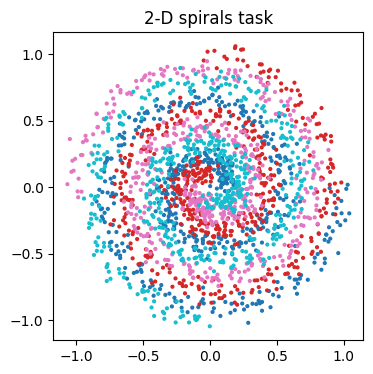

In [ ]:
CONFIG = dict(
    # architecture
    input_size=2, hidden_size=32, output_size=4,
    tau=2, forward_steps=3, weight_norm=1.0,
    # seeds: identical network init and data order for every rule
    network_seed=42, data_seed=123, probe_seed=7,
    # training
    total_steps=6000, chunk_size=1000,
    # local-redundancy probe
    n_probe=64, sigma=0.1, eps=1.0, score='gaussian',
    probe_lo=-1.2, probe_hi=1.2,
    # baselines
    probe_populations=['H1E', 'H2E'],
    device='cpu',
)

LOCAL_RULES = {
    'Backprop':   {'rule': 'Backprop',          'lr': 1e-3, 'builder': build_ei_network},
    'Hebbian':    {'rule': 'Hebb_WeightNorm_4', 'lr': 1e-4, 'builder': build_ei_network,
                   'kwargs': {'sign': 1}},
    "Oja's rule": {'rule': 'Ojas_rule',         'lr': 1e-4, 'builder': build_ei_network},
    'BCM':        {'rule': 'BCM_4',             'lr': 1e-4, 'builder': build_ei_network,
                   'kwargs': {'theta_tau': 10.0, 'k': 0.1, 'sign': 1}},
}

DENDRITIC_RULES = {
    'Backprop (dend. arch.)': {'rule': 'Backprop', 'lr': 1e-3,
                               'builder': build_dendritic_network, 'forward_steps': 12},
    'LDS':  {'rule': 'BP_like_2E', 'lr': 1e-4, 'builder': build_dendritic_network,
             'forward_steps': 12, 'kwargs': {'relu_gate': True, 'stochastic': False}},
    'TCH':  {'rule': 'Hebbian_Temporal_Contrast', 'lr': 1e-4,
             'builder': build_dendritic_network, 'forward_steps': 12},
    'BTSP': {'rule': 'BTSP_19', 'lr': 1e-4, 'builder': build_dendritic_network,
             'forward_steps': 12,
             'kwargs': {'temporal_discount': 0.01, 'neg_rate_th': 0.0}},
}

train_dl, val_dl, data_generator, (X_all, Y_all) = spiral_dataloaders(
    n_samples=2000, n_classes=CONFIG['output_size'], noise=0.05, seed=0)
print('train samples', len(train_dl.dataset), ' val samples', len(val_dl.dataset))

_, xs, ys = next(iter(val_dl))
plt.figure(figsize=(4, 4))
plt.scatter(X_all[:, 0], X_all[:, 1], c=Y_all.argmax(1), s=4, cmap='tab10')
plt.title('2-D spirals task'); plt.axis('equal'); plt.show()

## Run the self-tests

In [ ]:
print('Self-tests')
test_forward_matches_plain_mlp()
test_gradients_match_autograd()
test_plastic_parameters_covers_weights()
test_dendritic_balance()
test_dendritic_error_is_signed()
test_rules_actually_learn()
test_per_sample_vs_batched_estimator()
print('all self-tests passed')

Self-tests
  forward pass == plain ReLU MLP                       OK
  probe gradients == explicit-MLP autograd             OK
  Backprop           plastic weights=3   legacy filter would find 3
  Hebb_WeightNorm_4  plastic weights=3   legacy filter would find 0
  Ojas_rule          plastic weights=3   legacy filter would find 0
  BCM_4              plastic weights=3   legacy filter would find 0
  mean |forward dendritic state| H1E      = 8.789e-05
  mean |forward dendritic state| H2E      = 3.185e-05
  dendritic E/I cancellation                           OK
  hidden plateaus: 0 positive, 64 negative
  Backprop                 sum|dW| after 25 steps = 3.869e+00
  Hebbian                  sum|dW| after 25 steps = 2.244e-02
  Oja's rule               sum|dW| after 25 steps = 2.981e-02
  BCM                      sum|dW| after 25 steps = 2.751e-03
  Backprop (dend. arch.)   sum|dW| after 25 steps = 2.516e+00
  LDS                      sum|dW| after 25 steps = 1.699e-03
  TCH               

---
# Part 8 — Experiment A: purely local rules

Backprop, Hebbian, Oja and BCM on the E/I architecture. Same initialisation,
same data order, same probe inputs; only the plasticity rule differs.


=== Backprop (Backprop, lr=0.001) ===
  step      0 | acc 0.235 | R*      705.2 | |W|   4.892 | d(init)   0.000 | dormant 0.000 | train|g|^2      1.182
  step   1000 | acc 0.230 | R*      870.6 | |W|   5.672 | d(init)   2.201 | dormant 0.000 | train|g|^2      1.383
  step   2000 | acc 0.260 | R*      797.3 | |W|   5.779 | d(init)   2.574 | dormant 0.000 | train|g|^2      1.265
  step   3000 | acc 0.215 | R*      763.9 | |W|   5.841 | d(init)   2.735 | dormant 0.000 | train|g|^2      1.209
  step   4000 | acc 0.222 | R*      739.5 | |W|   5.872 | d(init)   2.948 | dormant 0.000 | train|g|^2      1.181
  step   5000 | acc 0.268 | R*      705.5 | |W|   5.960 | d(init)   3.124 | dormant 0.000 | train|g|^2      1.169
  step   6000 | acc 0.252 | R*      719.7 | |W|   5.860 | d(init)   3.005 | dormant 0.000 | train|g|^2      1.183

=== Hebbian (Hebb_WeightNorm_4, lr=0.0001) ===
  step      0 | acc 0.235 | R*      705.2 | |W|   4.892 | d(init)   0.000 | dormant 0.000 | train|g|^2      1.182
 

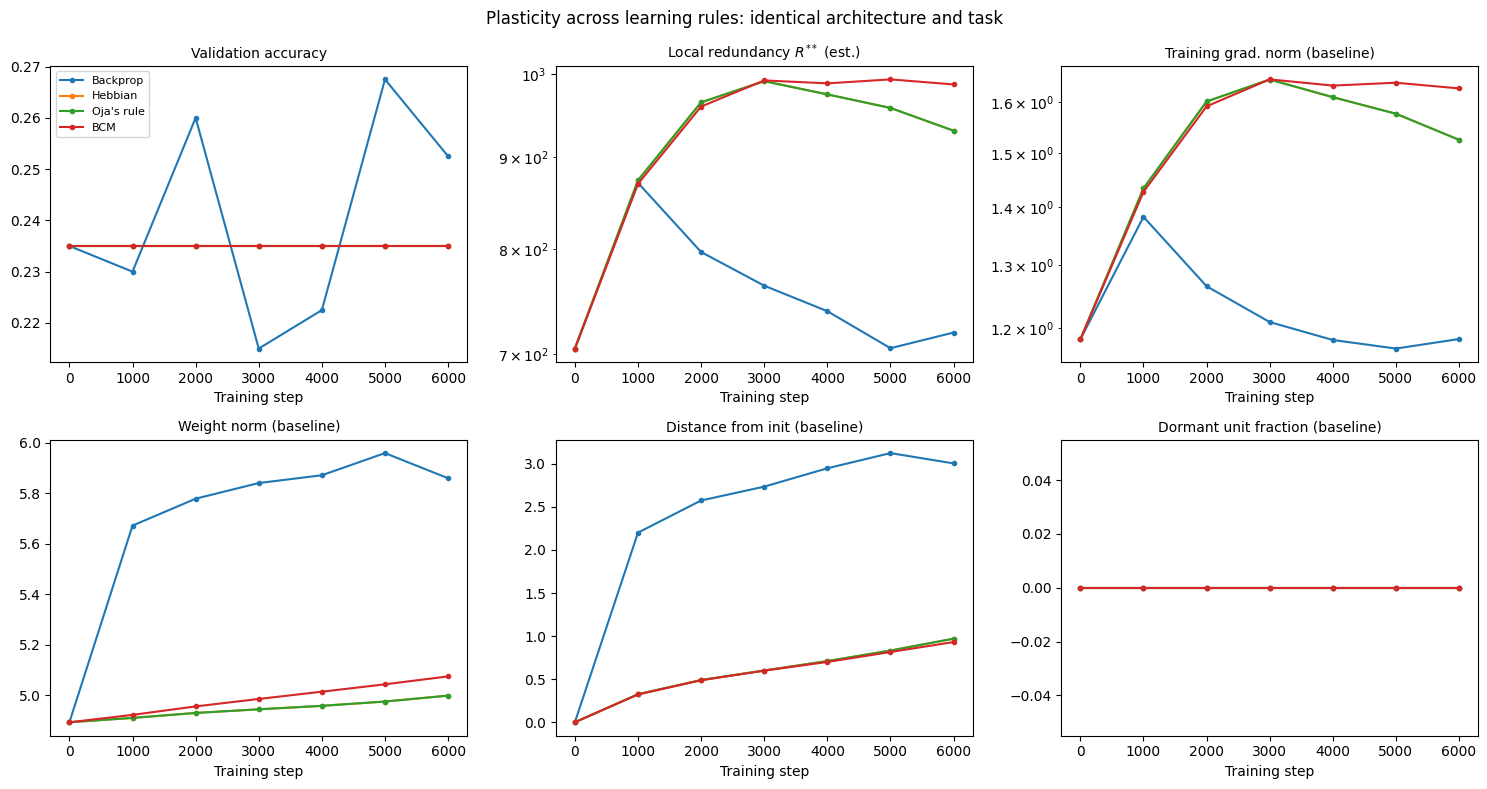

In [ ]:
histories_local, networks_local = run_experiment(
    LOCAL_RULES, train_dl, val_dl, CONFIG, data_generator=data_generator)
fig = plot_histories(histories_local)
plt.show()

---
# Part 9 — Experiment B: dendritic target propagation

LDS, TCH and BTSP on the dendritic architecture, with Backprop on the same
architecture as a reference. This is the comparison the original notebook was
reaching for; it only becomes meaningful once the Dend-I cancellation is in
place (see `test_dendritic_balance`).

This cell is slower — `forward_steps=12` means each training step runs twelve
settling sub-steps plus a twelve-step backward equilibration.


=== Backprop (dend. arch.) (Backprop, lr=0.001) ===
  dendritic balance at init (should be ~0): H1E=4.16e-05, H2E=1.70e-05
  step      0 | acc 0.240 | R*      951.3 | |W|   4.810 | d(init)   0.000 | dormant 0.000 | train|g|^2      1.543
  step   1000 | acc 0.268 | R*       1042 | |W|   5.673 | d(init)   2.312 | dormant 0.000 | train|g|^2      1.565
  step   2000 | acc 0.265 | R*        938 | |W|   5.832 | d(init)   2.768 | dormant 0.000 | train|g|^2       1.44
  step   3000 | acc 0.207 | R*      878.5 | |W|   5.907 | d(init)   2.958 | dormant 0.016 | train|g|^2      1.345
  step   4000 | acc 0.233 | R*      835.6 | |W|   5.990 | d(init)   3.192 | dormant 0.016 | train|g|^2      1.262
  step   5000 | acc 0.260 | R*      788.7 | |W|   6.058 | d(init)   3.324 | dormant 0.016 | train|g|^2      1.246
  step   6000 | acc 0.325 | R*      804.8 | |W|   5.970 | d(init)   3.222 | dormant 0.016 | train|g|^2      1.255

=== LDS (BP_like_2E, lr=0.0001) ===
  dendritic balance at init (should be ~0

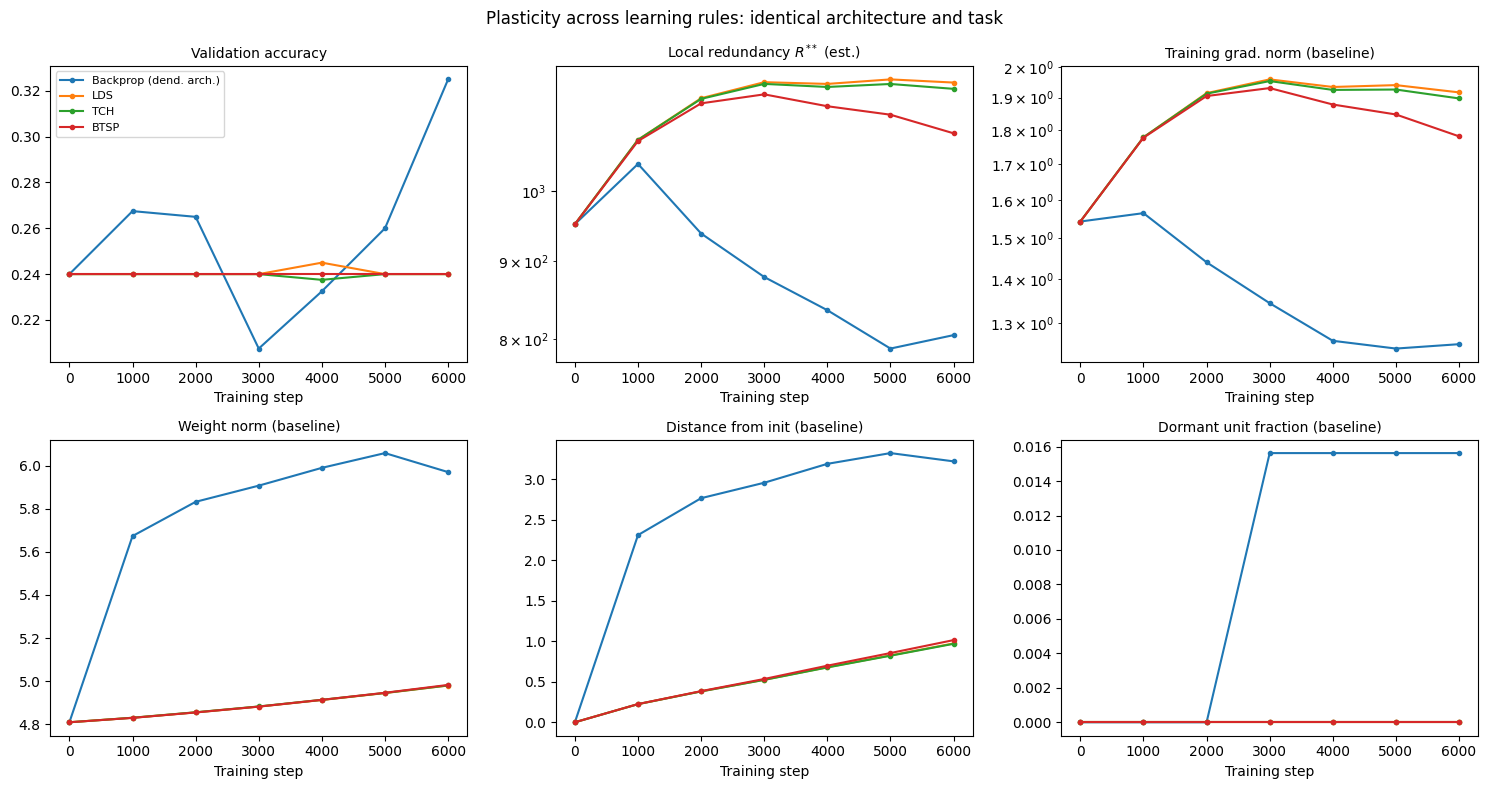

In [ ]:
histories_dend, networks_dend = run_experiment(
    DENDRITIC_RULES, train_dl, val_dl, CONFIG, data_generator=data_generator)
fig = plot_histories(histories_dend)
plt.show()

---
# Part 10 — Reading the results

A few things to look at, and a few traps.

* **Local redundancy vs. the baselines.** The paper's claim is that `R**` tracks
  trainability in a way the cheap baselines do not. The interesting panels are
  therefore the ones where `R**` and, say, dormant-unit fraction *disagree*.
* **Absolute values are not comparable across `σ`, `ε` or `n_probe`.** The
  Gaussian score divides by `σ²`, so halving `σ` quadruples every number.
  Only compare curves computed with identical probe settings.
* **`R**` scales with parameter count.** It is a sum of squared gradients over
  all plastic parameters. Comparing architectures with different parameter
  counts needs normalisation; comparing rules on the *same* architecture, as
  here, does not.
* **Hebbian and Oja are unsupervised.** They never see the target, so low
  accuracy is expected and is not evidence of lost plasticity. Read their
  `R**` curves as "how much capacity remains", not "how well is it learning".
* **Run more than one seed** before drawing conclusions. Vary
  `CONFIG['network_seed']` and `CONFIG['data_seed']` together and plot the
  spread; single-seed differences on this task are not reliable.

---
# Part 11 — Scaling up to MNIST

The same code runs on MNIST with `input_size=784`, `img_side=28` (which
switches the probe to the shape-based synthetic memorization images of §3.6)
and a larger hidden size. This is much slower: single-sample training with
multi-step settling is the bottleneck, and Colab CPU manages roughly
100–300 steps/second on the E/I architecture.

Start with `total_steps=5000` to sanity-check, then scale.

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 338kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.58MB/s]



=== Backprop (Backprop, lr=0.001) ===
  step      0 | acc 0.102 | R*       4098 | |W|   1.608 | d(init)   0.000 | dormant 0.000 | train|g|^2     0.5634
  step   1000 | acc 0.261 | R*       7469 | |W|   2.519 | d(init)   2.199 | dormant 0.000 | train|g|^2      2.387
  step   2000 | acc 0.268 | R*       7883 | |W|   2.567 | d(init)   2.261 | dormant 0.000 | train|g|^2      2.311
  step   3000 | acc 0.278 | R*       7936 | |W|   2.536 | d(init)   2.233 | dormant 0.000 | train|g|^2      2.394
  step   4000 | acc 0.199 | R*       7161 | |W|   2.484 | d(init)   2.169 | dormant 0.000 | train|g|^2      2.201
  step   5000 | acc 0.246 | R*       7343 | |W|   2.549 | d(init)   2.250 | dormant 0.000 | train|g|^2      2.331

=== Hebbian (Hebb_WeightNorm_4, lr=0.0001) ===
  step      0 | acc 0.102 | R*       4098 | |W|   1.608 | d(init)   0.000 | dormant 0.000 | train|g|^2     0.5634
  step   1000 | acc 0.102 | R*       5235 | |W|   1.727 | d(init)   0.736 | dormant 0.000 | train|g|^2      2.197
 

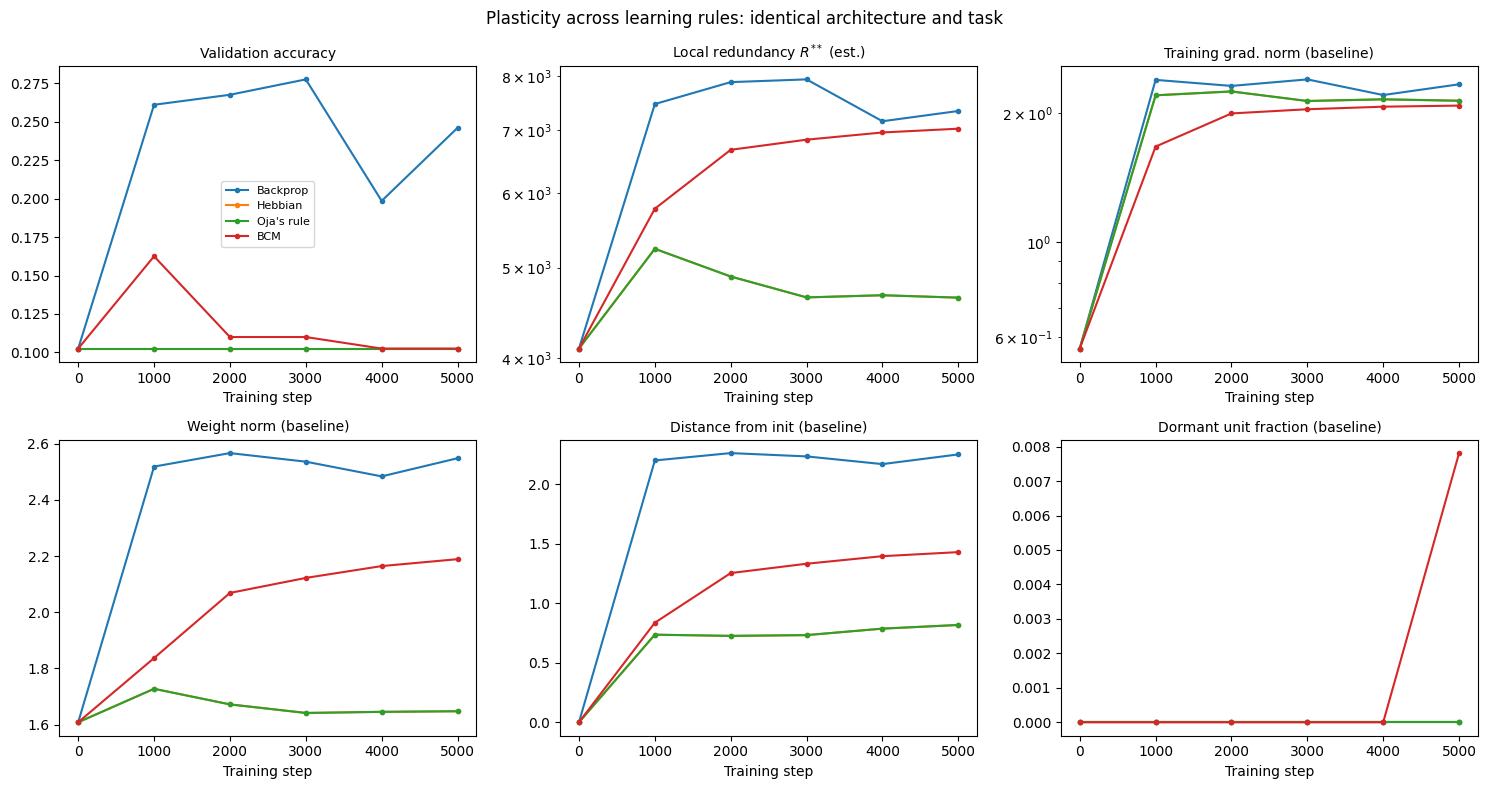

In [ ]:
RUN_MNIST = True   # set True to run

if RUN_MNIST:
    import torchvision
    import torchvision.transforms as T

    tf = T.Compose([T.ToTensor(), T.Lambda(torch.flatten)])
    tr = torchvision.datasets.MNIST('./data', train=True, download=True, transform=tf)
    te = torchvision.datasets.MNIST('./data', train=False, download=True, transform=tf)
    eye = torch.eye(10)
    mnist_train = [(i, d, eye[t]) for i, (d, t) in enumerate(tr)]
    mnist_test = [(i, d, eye[t]) for i, (d, t) in enumerate(te)]

    mnist_gen = torch.Generator()
    mnist_train_dl = torch.utils.data.DataLoader(mnist_train[:50000], batch_size=1,
                                                 shuffle=True, generator=mnist_gen)
    mnist_val_dl = torch.utils.data.DataLoader(mnist_train[-10000:][:2000],
                                               batch_size=2000, shuffle=False)

    MNIST_CONFIG = dict(CONFIG)
    MNIST_CONFIG.update(input_size=784, hidden_size=128, output_size=10,
                        img_side=28, total_steps=5000, chunk_size=1000,
                        n_probe=32, probe_populations=['H1E', 'H2E'])

    histories_mnist, _ = run_experiment(LOCAL_RULES, mnist_train_dl, mnist_val_dl,
                                        MNIST_CONFIG, data_generator=mnist_gen)
    plot_histories(histories_mnist)
    plt.show()
else:
    print('MNIST section skipped — set RUN_MNIST = True to run it.')


=== Backprop (dend. arch.) (Backprop, lr=0.001) ===
  dendritic balance at init (should be ~0): H1E=2.12e-05, H2E=1.25e-06
  step      0 | acc 0.110 | R*       2787 | |W|   1.589 | d(init)   0.000 | dormant 0.004 | train|g|^2     0.5389
  step   1000 | acc 0.203 | R*       6689 | |W|   2.545 | d(init)   2.220 | dormant 0.004 | train|g|^2      2.233
  step   2000 | acc 0.142 | R*       6680 | |W|   2.507 | d(init)   2.195 | dormant 0.000 | train|g|^2      2.157
  step   3000 | acc 0.179 | R*       5469 | |W|   2.427 | d(init)   2.107 | dormant 0.000 | train|g|^2      2.135
  step   4000 | acc 0.154 | R*       6651 | |W|   2.572 | d(init)   2.284 | dormant 0.004 | train|g|^2      2.134
  step   5000 | acc 0.204 | R*       5792 | |W|   2.496 | d(init)   2.203 | dormant 0.000 | train|g|^2      2.176

=== LDS (BP_like_2E, lr=0.0001) ===
  dendritic balance at init (should be ~0): H1E=2.12e-05, H2E=1.25e-06
  step      0 | acc 0.110 | R*       2787 | |W|   1.589 | d(init)   0.000 | dormant 

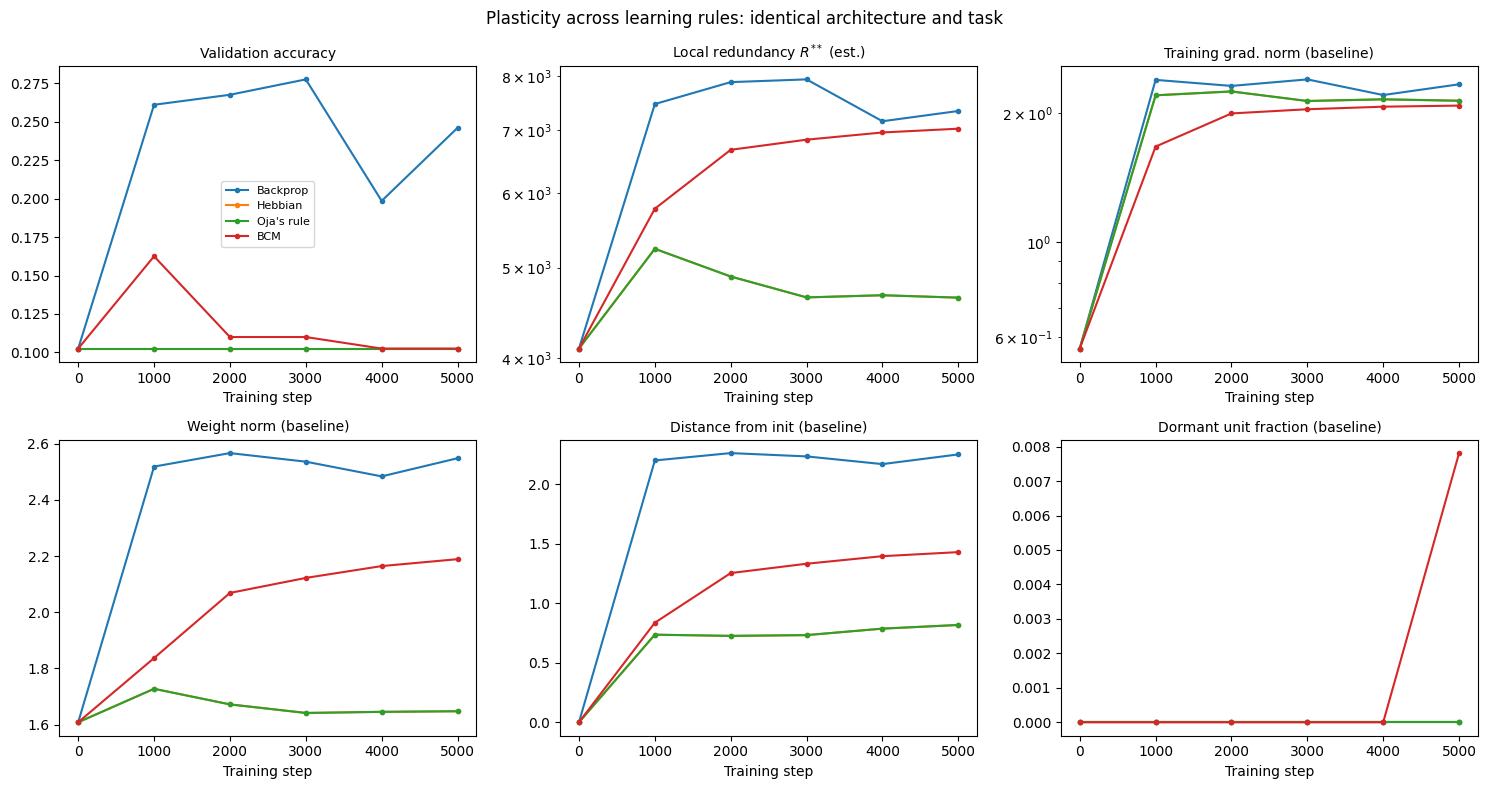

In [ ]:
RUN_MNIST = True   # set True to run

if RUN_MNIST:
    import torchvision
    import torchvision.transforms as T

    tf = T.Compose([T.ToTensor(), T.Lambda(torch.flatten)])
    tr = torchvision.datasets.MNIST('./data', train=True, download=True, transform=tf)
    te = torchvision.datasets.MNIST('./data', train=False, download=True, transform=tf)
    eye = torch.eye(10)
    mnist_train = [(i, d, eye[t]) for i, (d, t) in enumerate(tr)]
    mnist_test = [(i, d, eye[t]) for i, (d, t) in enumerate(te)]

    mnist_gen = torch.Generator()
    mnist_train_dl = torch.utils.data.DataLoader(mnist_train[:50000], batch_size=1,
                                                 shuffle=True, generator=mnist_gen)
    mnist_val_dl = torch.utils.data.DataLoader(mnist_train[-10000:][:2000],
                                               batch_size=2000, shuffle=False)

    MNIST_CONFIG = dict(CONFIG)
    MNIST_CONFIG.update(input_size=784, hidden_size=128, output_size=10,
                        img_side=28, total_steps=5000, chunk_size=1000,
                        n_probe=32, probe_populations=['H1E', 'H2E'])

    histories_dend, networks_dend = run_experiment(DENDRITIC_RULES, mnist_train_dl, mnist_val_dl,
                                                   MNIST_CONFIG, data_generator=mnist_gen)
    plot_histories(histories_mnist)
    plt.show()
else:
    print('MNIST section skipped — set RUN_MNIST = True to run it.')

---
## Provenance

The EIANN reimplementation above was transcribed from the v1.0.0 sources
published at https://milstein-lab.github.io/EIANN (modules `network`,
`rules.backprop`, `rules.backprop_like`, `rules.hebbian`, `rules.btsp`,
`rules.weight_functions`, `utils.weight_inits`, `utils.activations`).

If you have the repository zip to hand, diffing it against Part 1 is worth
doing — the docs build reflects `main`, and a tagged release may differ.

**Cite both papers if you use this:**

* Galloni A.R., Peddada A., Chennawar Y., Milstein A.D. (2026). Cellular and
  subcellular specialization enables biology-constrained deep learning.
  *Cell Reports* 45:117159. doi:10.1016/j.celrep.2026.117159
* Local Redundancy: An Information-Theoretic Measure of Plasticity from
  Synthetic Memorization. arXiv:2607.13432